# Compare Fourier and Polynomial Fits to show Fourier is "always" best 
## Rachel suggests looking into the gradient of the fit to the timeseries by doing the following
- Get day of year climatology (avg temp over time for each day)
- Also detrend that value so we have both detrended and raw
- Identify the points of maximum slope (gradient, will have one + and one -)
- Get error between that slope and Fourier or Polynomial fit's estimate, maybe plot as a scatter plot?

### does the slope at th eleading edge and trailing edge + the RMSE give evidence that the Fourier fit is the best one

# !!! 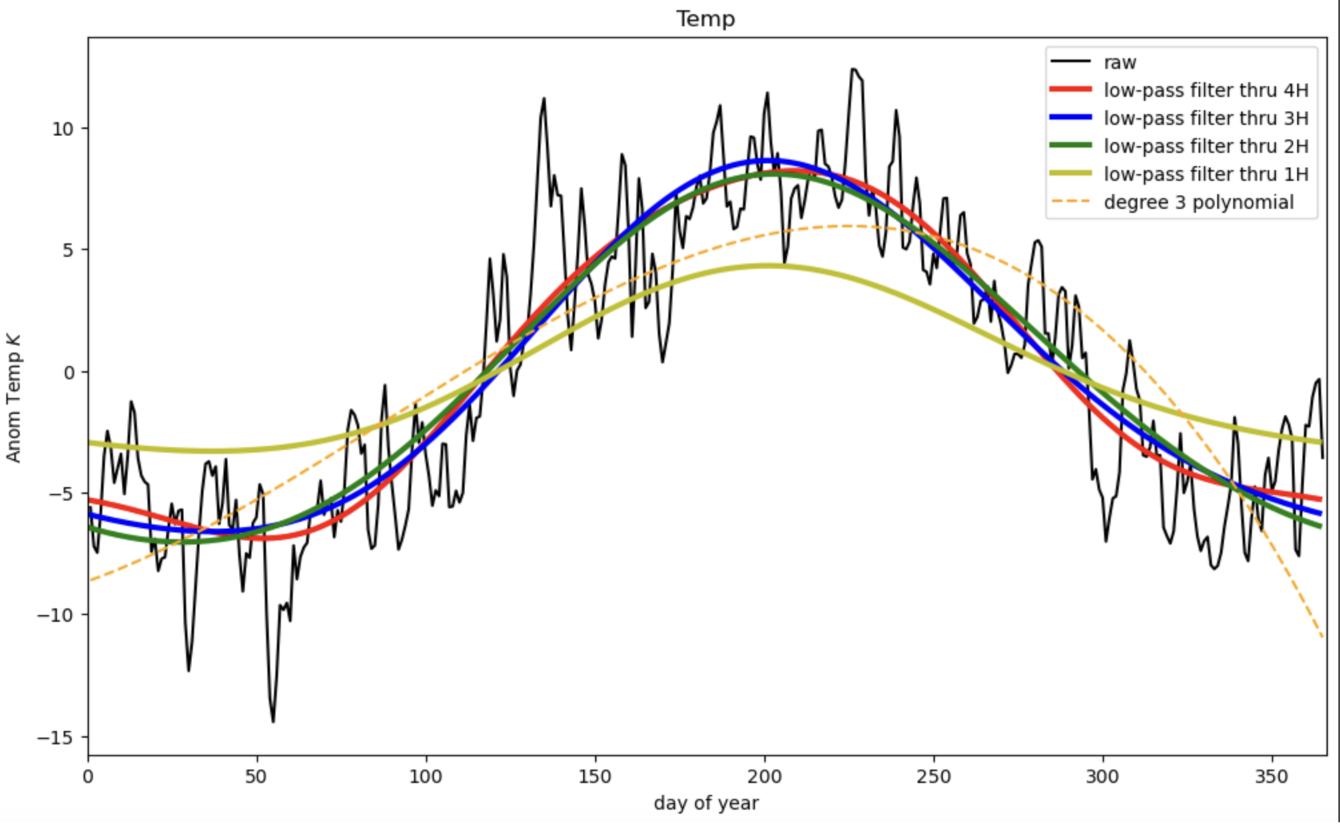

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import matplotlib.ticker as mticker
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

# Lat limits
nh_min = 23.5
nh_max = 70

In [ ]:
# helper functions

# def GetClimatology(tempdata, threshold):
#     '''
#     Function takes in the temperature data for a single grid cell and calculates the mean across all years
#     and also computes the linear trend across all years, subtracts it from the temp data, and produces the 
#     detrended mean across all years

    
#     Args:
#         tempdata: xarray of temperature data for a single grid cell for all years of interest
#         threshold: xarray for the 75th percentile threshold to use

#     Returns:
#         climtemp - mean temp across all years
#         detrend - detrended mean temp across all years

#     '''
    
#     # default values
#     climtemp = 0
#     detrend = 0

#     # is it this easy?
#     climtemp = 


    

## load in all of the analysis years, global t2m data, and merge in lsm and coastal flags

In [5]:
%%time

# takes 3 sec to load dask array

# try a different method than the one below
# in this case, don't merge with lsm and coastal yet since we can do that later on the grouped results
input_path = '../../../Data/ERA5-global/Analysis/*/download_daily_mean_2m_temperature_*.nc'
ds_base = xr.open_mfdataset(input_path)


CPU times: user 1.86 s, sys: 857 ms, total: 2.72 s
Wall time: 3.16 s


## !!! The below operation takes too long?? - need to come up with something else or just let it run, I guess. Waited at least 60 minutes and it didn't finish

In [10]:
# %%time

# # takes XX min to load

# # start with one year and lsm then coastal and add a coordinate for the year
# year = 1990
# input_path = '../../../Data/ERA5-global/Analysis/'+str(year)+'/download_daily_mean_2m_temperature_*.nc'
# #input_p = '../../../Data/ERA5-global/Analysis/1990/download_daily_mean_2m_temperature_*'
# ds_base = xr.open_mfdataset(input_path)
# ds_base = ds_base.merge(ds_lsm) # add lsm
# ds_base = ds_base.merge(results_ds) # add coastal flag
# #ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# # loop thru remaining years and also add time coord
# input_years = np.arange(1991,2024,1)

# for year in input_years:
#     input_path = '../../../Data/ERA5-global/Analysis/'+str(year)+'/download_daily_mean_2m_temperature_*.nc'
#     ds_i = xr.open_mfdataset(input_path)
#     ds_i = ds_i.merge(ds_lsm)
#     ds_i = ds_i.merge(results_ds)
# #    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
#     ds_base = ds_base.merge(ds_i)

# #ds_base

In [4]:
ds_base

<xarray.Dataset> Size: 52GB
Dimensions:      (time: 12618, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 101kB 1990-01-01 ... 2024-07-18
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 52GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-07T04:55 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [3]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats =ds_base.lat.values[:num_lat]
loop_lons = ds_base.lon.values[:num_lon]

NameError: name 'ds_base' is not defined

## Drop leap years so grouping by DOY works across years

In [31]:
%%time
ds = ds_base.convert_calendar('noleap', use_cftime=None)

# alows us to slice years
ds = ds.convert_calendar('365_day')
ds

CPU times: user 82.7 ms, sys: 5.46 ms, total: 88.2 ms
Wall time: 85.4 ms


<xarray.Dataset> Size: 52GB
Dimensions:      (time: 12609, lat: 721, lon: 1440)
Coordinates:
  * time         (time) object 101kB 1990-01-01 00:00:00 ... 2024-07-18 00:00:00
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 52GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-07T04:55 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

## Reduce to 1990-2023, NH midlatitudes only to avoid needing to consider NH/SH seasonal differences

In [35]:
# Lat limits
nh_min = 23.5
nh_max = 70

ds = ds.sel(time=slice('1990','2023'), lat=slice(nh_min, nh_max))
ds

<xarray.Dataset> Size: 13GB
Dimensions:      (time: 12410, lat: 187, lon: 1440)
Coordinates:
  * time         (time) object 99kB 1990-01-01 00:00:00 ... 2023-12-31 00:00:00
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 13GB dask.array<chunksize=(31, 187, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-07T04:55 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

## Here just get climatology by DOY not detrended

In [37]:
# from https://comptools.climatematch.io/tutorials/W1D1_ClimateSystemOverview/student/W1D1_Tutorial5.html
ds_daily_clim = ds.t2m.groupby("time.dayofyear").mean()
ds_daily_clim

<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<stack, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * dayofyear    (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

## Detrend the data grouped by DOY and then compute climatology per grid cell

In [38]:
%%time

## takes 10 seconds

# got this from https://docs.coiled.io/blog/dask-detrending.html
def detrending_step(arr: xr.DataArray) -> xr.DataArray:
    # important: the rolling operation is applied within a group
    # here we remove the 30-year moving average
    return arr - arr.rolling(time=30, min_periods=1).mean()

# subtract rolling average, which gives us an anomaly value vs raw data
ds_detrend = ds.t2m.groupby("time.dayofyear").map(detrending_step)

# group by DOY and get anomaly
ds_daily_clim_detrend_an = ds_detrend.groupby("time.dayofyear").mean()

# compute the new detrended DOY cimatology by removing the anomaly amount
ds_daily_clim_detrend = ds_daily_clim - ds_daily_clim_detrend_an
ds_daily_clim_detrend

## this really should be done with polyfit instead of a moving average???

CPU times: user 9.5 s, sys: 145 ms, total: 9.65 s
Wall time: 9.66 s


<xarray.DataArray 't2m' (dayofyear: 365, lat: 187, lon: 1440)> Size: 393MB
dask.array<sub, shape=(365, 187, 1440), dtype=float32, chunksize=(1, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * dayofyear    (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [48]:
ds_detrend

<xarray.DataArray 't2m' (time: 12410, lat: 187, lon: 1440)> Size: 13GB
dask.array<getitem, shape=(12410, 187, 1440), dtype=float32, chunksize=(1, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 99kB 1990-01-01 00:00:00 ... 2023-12-31 00:00:00
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

## Plot both detrended climatology and climatological average for Vancouver by DOY

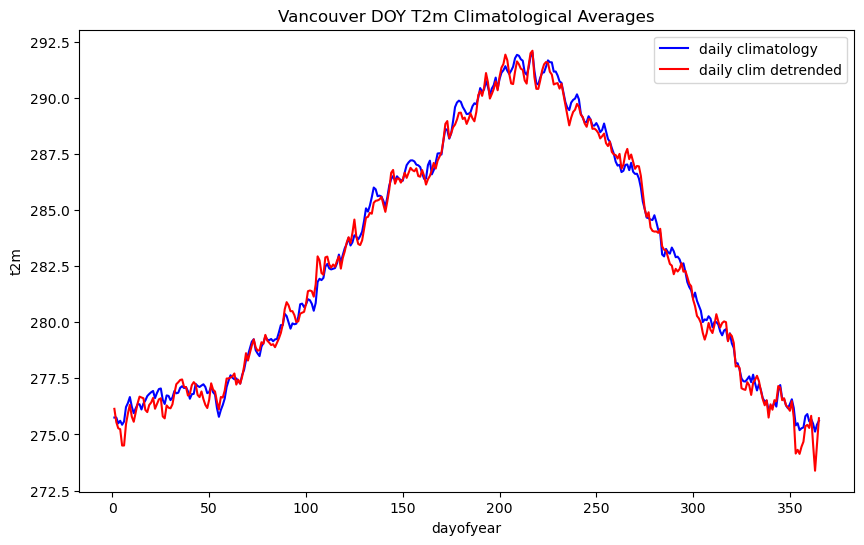

CPU times: user 3min 26s, sys: 1min 53s, total: 5min 20s
Wall time: 1min


In [39]:
%%time

# takes 1 minute

#test for Vancouver
input_lat = 49.246
input_lon = -123.116

plt.figure(figsize=(10,6))
ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='b', label="daily climatology")
ds_daily_clim_detrend.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='r', label="daily clim detrended")
plt.title("Vancouver DOY T2m Climatological Averages")
plt.legend()
plt.show()


## !!!! I was hoping that would be more smooth for finding the steepest gradient in the data to see which captures it better - polynomial or Fourier

### can we do a rolling average of the DOY data to smooth it out?

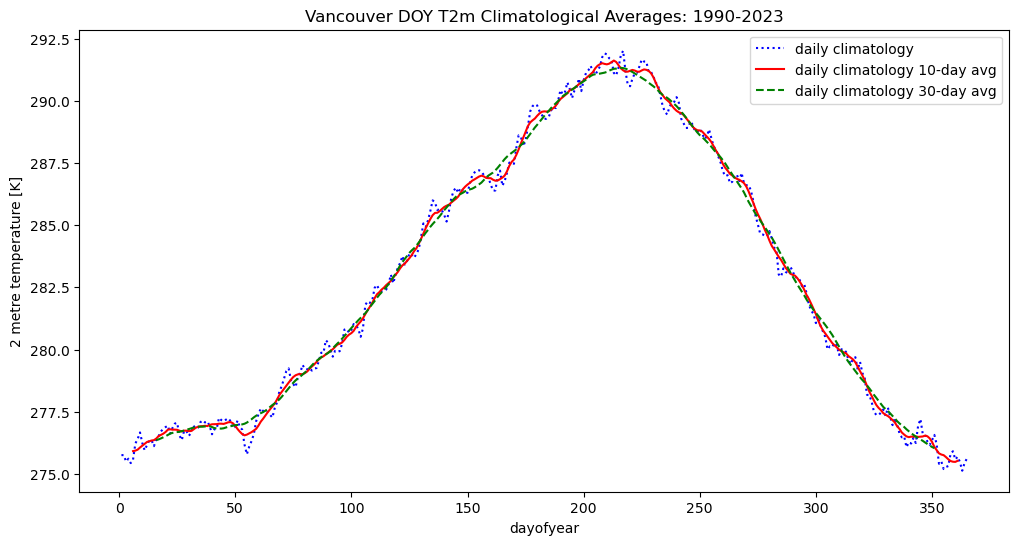

CPU times: user 1min 50s, sys: 1min 43s, total: 3min 34s
Wall time: 46.5 s


In [55]:
%%time

# takes 1 minute

#test for Vancouver
input_lat = 49.246
input_lon = -123.116

plt.figure(figsize=(12,6))
ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='b', label="daily climatology", linestyle='dotted')
ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").rolling(dayofyear=10,center=True).mean().plot(c='r', label="daily climatology 10-day avg")
ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").rolling(dayofyear=30,center=True).mean().plot(c='g', label="daily climatology 30-day avg", linestyle='dashed')
#ds_daily_clim_detrend.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='r', label="daily clim detrended")
plt.title("Vancouver DOY T2m Climatological Averages: 1990-2023")
plt.legend()
plt.show()


## Might be able to use the scipi detrend function on the grouped object via map()?
## nevermind, the below doesn't work - seems to kill the kernel so might have to manually detrend using numpy/xarray polyfit?

## 

In [9]:
# # move to the top if this works
# from scipy.signal import detrend

# # use scipi detrend to remove trend (cant apply mean because it is a numpy object without a "dim")
# def detrend_daily_clim(x):
#     return (detrend(x, type='linear'))#.mean()

In [ ]:
# %%time

# # takes XX min

# # for each day of the year, detrend it, and then get the mean of those detrended day of year temps
# ds_daily_clim_detrend = ds.t2m.groupby("time.dayofyear").map(detrend_daily_clim).mean()
# ds_daily_clim_detrend

## What about linear detrending first then grouping by DOY?

In [16]:
ds.t2m

<xarray.DataArray 't2m' (time: 12609, lat: 721, lon: 1440)> Size: 52GB
dask.array<where, shape=(12609, 721, 1440), dtype=float32, chunksize=(31, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 101kB 1990-01-01 00:00:00 ... 2024-07-18 00:00:00
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

In [22]:
34*365

12410

In [41]:
%%time
# from https://climate.usu.edu/people/yoshi/pyclm101/monthly.html

# -- Detorending
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

# -- Running mean
#ranm = anm.rolling(time=7, center=True).mean('time')
#rdanm = detrend_dim(ranm,'time',1)

# try detrending
ds_t2m_linear_detrend = detrend_dim(ds.t2m, 'time',1)
ds_t2m_linear_detrend


CPU times: user 76.5 ms, sys: 27.6 ms, total: 104 ms
Wall time: 165 ms


<xarray.DataArray (time: 12410, lat: 187, lon: 1440)> Size: 27GB
dask.array<sub, shape=(12410, 187, 1440), dtype=float64, chunksize=(31, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 99kB 1990-01-01 00:00:00 ... 2023-12-31 00:00:00
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

### OK, now group by DOY to get mean per DOY of the detrended values

In [42]:
%%time
ds_daily_clim_linear_detrend = ds_t2m_linear_detrend.groupby("time.dayofyear").mean()
ds_daily_clim_linear_detrend

CPU times: user 631 ms, sys: 39.8 ms, total: 671 ms
Wall time: 685 ms


<xarray.DataArray (dayofyear: 365, lat: 187, lon: 1440)> Size: 786MB
dask.array<stack, shape=(365, 187, 1440), dtype=float64, chunksize=(1, 187, 1440), chunktype=numpy.ndarray>
Coordinates:
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * dayofyear    (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [46]:
ds_daily_clim_linear_detrend.head(1).compute()

<xarray.DataArray (dayofyear: 1, lat: 1, lon: 1)> Size: 8B
array([[[-1.42544734]]])
Coordinates:
    realization  int64 8B 0
  * lat          (lat) float64 8B 23.5
  * lon          (lon) float64 8B -180.0
  * dayofyear    (dayofyear) int64 8B 1

### Plot all three now

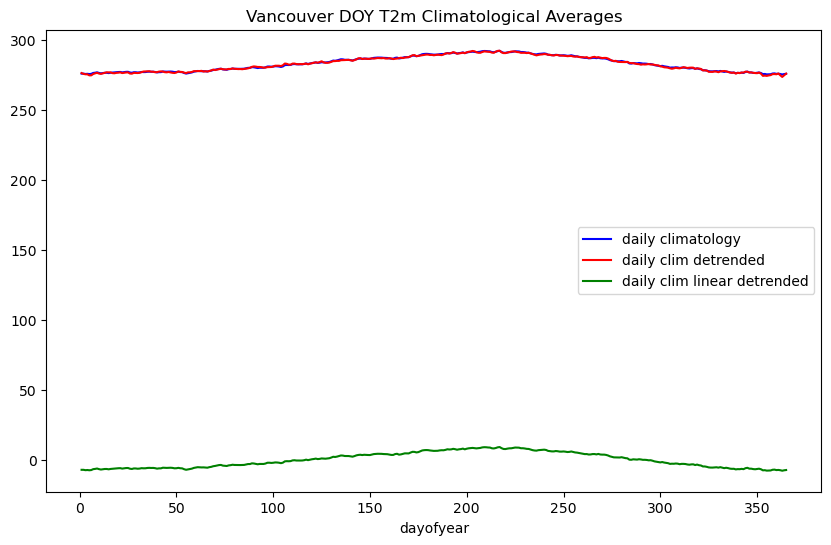

CPU times: user 6min 38s, sys: 8min 37s, total: 15min 16s
Wall time: 10min 58s


In [43]:
%%time

# takes 11 minutes

#test for Vancouver
input_lat = 49.246
input_lon = -123.116

plt.figure(figsize=(10,6))
ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='b', label="daily climatology")
ds_daily_clim_detrend.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='r', label="daily clim detrended")
ds_daily_clim_linear_detrend.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='g', label="daily clim linear detrended")
plt.title("Vancouver DOY T2m Climatological Averages")
plt.legend()
plt.show()


### plot the two detrended series

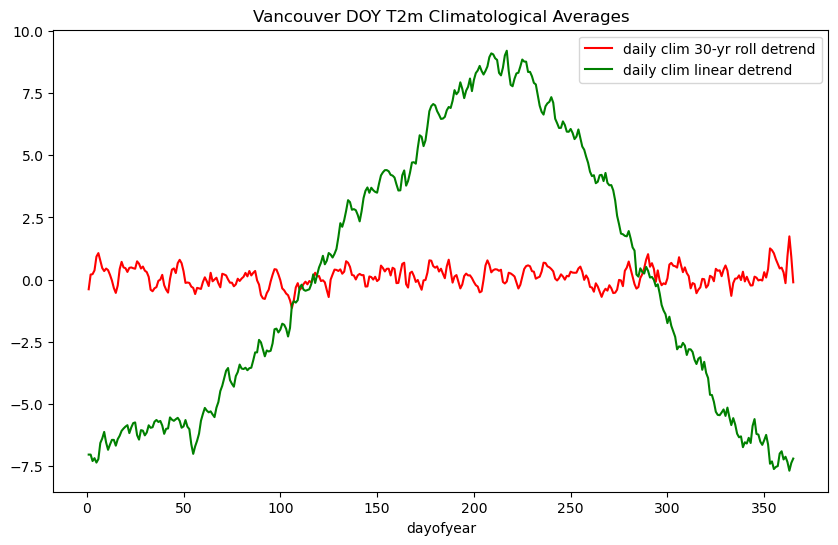

CPU times: user 5min 51s, sys: 7min 51s, total: 13min 43s
Wall time: 10min 31s


In [47]:
%%time

# takes XXX minutes

#test for Vancouver
input_lat = 49.246
input_lon = -123.116

plt.figure(figsize=(10,6))
#ds_daily_clim.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='b', label="daily climatology")
ds_daily_clim_detrend_an.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='r', label="daily clim 30-yr roll detrend")
ds_daily_clim_linear_detrend.sel(lat=input_lat, lon=input_lon, method="nearest").plot(c='g', label="daily clim linear detrend")
plt.title("Vancouver DOY T2m Climatological Averages")
plt.legend()
plt.show()



## Seems like I should either use the 30-day moving average climatology or perhaps a moving average of the linearly detrended climatology and then 
- get max + and - slope
- fit with polynomial and Fourier series
- - get max + and - slopes
- - compute RMSE and error in slopes from the DOY climatology
- Analyze results! Expect the Fourier can match the slopes much more closely on summer onset and end for land/coasts, and does as well or better for water

In [56]:
%%time
## time to save it out for re-use 

# add attributes first 
ds_daily_clim_linear_detrend.attrs["long_name"] = "Linearly detrended day of year mean temp (DOY in [1,365])"
ds_daily_clim_linear_detrend.attrs["units"] = "Degrees [K]"

ds_daily_clim_detrend.attrs["long_name"] = "30-year Rolling Avg detrended day of year mean temp (DOY in [1,365])"
ds_daily_clim_detrend.attrs["units"] = "Degrees [K]"

ds_daily_clim.attrs["long_name"] = "Day of year mean temp (DOY in [1,365])"
ds_daily_clim.attrs["units"] = "Degrees [K]"

ds_full = xr.Dataset(data_vars={'DOYClim':ds_daily_clim,
                               'DOYClimDetrend':ds_daily_clim_detrend,
                               'DOYClimLinDetrend':ds_daily_clim_linear_detrend})#,
                               #'lsm':ds_lsm.to_dataarray(),
                               #'Coastal':results_ds.to_dataarray()})

ds_full

CPU times: user 2.26 ms, sys: 1.11 ms, total: 3.37 ms
Wall time: 3.32 ms


<xarray.Dataset> Size: 2GB
Dimensions:            (lat: 187, lon: 1440, dayofyear: 365)
Coordinates:
    realization        int64 8B 0
  * lat                (lat) float64 1kB 23.5 23.75 24.0 ... 69.5 69.75 70.0
  * lon                (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * dayofyear          (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365
Data variables:
    DOYClim            (dayofyear, lat, lon) float32 393MB dask.array<chunksize=(1, 187, 1440), meta=np.ndarray>
    DOYClimDetrend     (dayofyear, lat, lon) float32 393MB dask.array<chunksize=(1, 187, 1440), meta=np.ndarray>
    DOYClimLinDetrend  (dayofyear, lat, lon) float64 786MB dask.array<chunksize=(1, 187, 1440), meta=np.ndarray>

In [57]:
%%time
# takes 11 min

# load to bring into memory for writing?
ds_full.load()
ds_full

CPU times: user 5min 40s, sys: 8min 43s, total: 14min 23s
Wall time: 11min 12s


<xarray.Dataset> Size: 2GB
Dimensions:            (lat: 187, lon: 1440, dayofyear: 365)
Coordinates:
    realization        int64 8B 0
  * lat                (lat) float64 1kB 23.5 23.75 24.0 ... 69.5 69.75 70.0
  * lon                (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * dayofyear          (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365
Data variables:
    DOYClim            (dayofyear, lat, lon) float32 393MB 296.2 296.2 ... 250.6
    DOYClimDetrend     (dayofyear, lat, lon) float32 393MB 296.1 296.0 ... 250.3
    DOYClimLinDetrend  (dayofyear, lat, lon) float64 786MB -1.425 ... -13.55

In [58]:
ds_full.nbytes

1572611144

## output to file for later re-use

In [59]:
output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1990-2023_DOYClimatologyNH.nc'
ds_full.to_netcdf(output_path)

# !!!!!!!!!!!!!!!!

## !!! START HERE NOW
## Re-load it

## START HERE NOWBelow can be used as a guide but we need to do Fourier Fits per grid cell now that we have it as DOY climatology

In [2]:
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1990-2023_DOYClimatologyNH.nc'
ds_full = xr.open_dataset(input_path)
ds_full

<xarray.Dataset> Size: 2GB
Dimensions:            (lat: 187, lon: 1440, dayofyear: 365)
Coordinates:
    realization        int64 8B ...
  * lat                (lat) float64 1kB 23.5 23.75 24.0 ... 69.5 69.75 70.0
  * lon                (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * dayofyear          (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365
Data variables:
    DOYClim            (dayofyear, lat, lon) float32 393MB ...
    DOYClimDetrend     (dayofyear, lat, lon) float32 393MB ...
    DOYClimLinDetrend  (dayofyear, lat, lon) float64 786MB ...

In [3]:
# get 75th percentile values - might need them
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values

array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

## Seems like I should either use the 30-day moving average climatology or perhaps a moving average of the linearly detrended climatology and then 
- Calculate gradient for each DOY from rolling avg climatology (was:get max + and - slope)
- fit DOY climatology with polynomial and Fourier series
  - Calculate gradient for each DOY (was: get max + and - slopes)
  - compute RMSE and error in slopes from the DOY climatology
  - compute error on start/end day of "summer" based on above 75th percentile days in DOY climatology
- Analyze results! Expect the Fourier can match the slopes much more closely on summer onset and end for land/coasts, and does as well or better for water
- Might also be good to understand the impact of fourier and poly fits on choice of start/end - does one or the other tend to find them to each be earlier/later?

In [5]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116

In [4]:
%%time
# check computing the rolling avg for each grid cell

# min_periods = 2 to handle edges
ds_daily_clim_30dayroll2 = ds_full.DOYClim.rolling(dayofyear=30,center=True, min_periods=2).mean()

# without setting min_periods
ds_daily_clim_30dayroll = ds_full.DOYClim.rolling(dayofyear=30,center=True).mean()


#ds_daily_clim_30dayroll.sel(lat=input_lat, lon=input_lon, method='nearest')


CPU times: user 321 ms, sys: 295 ms, total: 616 ms
Wall time: 743 ms


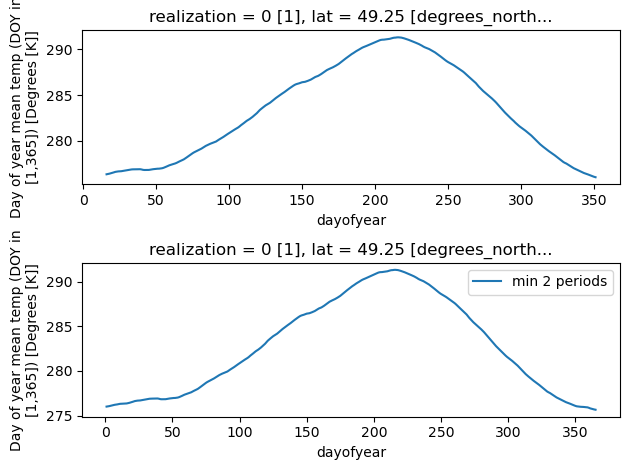

In [6]:
# plot both to see edge effects
plt.figure()
plt.subplot(211)
ds_daily_clim_30dayroll.sel(lat=input_lat, lon=input_lon, method='nearest').plot(label='no min')
plt.subplot(212)
ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest').plot(label='min 2 periods')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
ds_daily_clim_30dayroll.sel(lat=input_lat, lon=input_lon, method='nearest')

<xarray.DataArray 'DOYClim' (dayofyear: 365)> Size: 1kB
array([      nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan, 276.35736, 276.3871 , 276.4264 ,
       276.47107, 276.51263, 276.5675 , 276.61996, 276.64822, 276.67178,
       276.68045, 276.69223, 276.7204 , 276.74203, 276.77216, 276.79944,
       276.8328 , 276.85956, 276.88364, 276.89716, 276.89832, 276.89862,
       276.90564, 276.91428, 276.91205, 276.8838 , 276.84167, 276.8267 ,
       276.82523, 276.8205 , 276.83386, 276.8627 , 276.8957 , 276.9155 ,
       276.9363 , 276.9576 , 276.96744, 276.9713 , 276.99057, 277.01605,
       277.0623 , 277.12683, 277.1949 , 277.2724 , 277.33875, 277.39178,
       277.44153, 277.48517, 277.5412 , 277.60648, 277.69125, 277.7689 ,
       277.83737, 277.91644, 277.99554, 278.09753, 278.2131 , 278.32843,
       278.44693, 278.556  , 278.66452, 278.76044, 278.83917, 278.912  ,
       278.99503, 279.07535, 279.16077, 279.25967, 279.3648 , 279.46326,
       279.54196, 279.6173 , 279.6903 , 279.75192, 279.80466, 279.86316,
       279.938  , 280.04813, 280.14874, 280.24207, 280.32852, 280.43704,
       280.5502 , 280.655  , 280.7616 , 280.8665 , 280.9717 , 281.07413,
       281.17883, 281.272  , 281.35925, 281.45987, 281.57602, 281.71085,
       281.82648, 281.94818, 282.0793 , 282.19852, 282.2948 , 282.39517,
       282.50723, 282.63135, 282.7662 , 282.89767, 283.04346, 283.2121 ,
...
       288.3549 , 288.2616 , 288.153  , 288.03488, 287.92444, 287.82843,
       287.72473, 287.6071 , 287.47784, 287.32745, 287.18094, 287.0412 ,
       286.90106, 286.76422, 286.6227 , 286.47754, 286.32474, 286.13034,
       285.94482, 285.78156, 285.61777, 285.46112, 285.32166, 285.1887 ,
       285.05276, 284.91632, 284.78674, 284.64667, 284.50052, 284.34143,
       284.17538, 283.99094, 283.8149 , 283.6301 , 283.4537 , 283.2721 ,
       283.09662, 282.9343 , 282.7667 , 282.61557, 282.46414, 282.32062,
       282.17416, 282.00803, 281.8596 , 281.72287, 281.58694, 281.47272,
       281.35553, 281.2345 , 281.1201 , 280.99106, 280.8637 , 280.727  ,
       280.5923 , 280.4343 , 280.27997, 280.1251 , 279.95422, 279.79153,
       279.64383, 279.50702, 279.3794 , 279.25504, 279.1332 , 279.01086,
       278.8853 , 278.77637, 278.67572, 278.55862, 278.43796, 278.31268,
       278.17648, 278.0595 , 277.93314, 277.81458, 277.69266, 277.6039 ,
       277.53015, 277.42926, 277.32556, 277.2292 , 277.11795, 277.02774,
       276.95148, 276.88486, 276.79276, 276.71283, 276.63608, 276.5663 ,
       276.49814, 276.44315, 276.3871 , 276.32877, 276.26288, 276.20273,
       276.1416 , 276.08154, 276.03577,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan],
      dtype=float32)
Coordinates:
    realization  int64 8B 0
    lat          float64 8B 49.25
    lon          float64 8B -123.0
  * dayofyear    (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Attributes:
    long_name:              Day of year mean temp (DOY in [1,365])
    units:                  Degrees [K]
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

## Looks like it is OK to use the rolling avg with min_periods=2 to handle edges and not "lose" data

In [8]:
van_30day_roll = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
thresh = c_75.sel(lat=input_lat, lon=input_lon, method='nearest')

# extract DOY and T2m values for those days
x1 = van_30day_roll.dayofyear.values
y1 = van_30day_roll.values

#x1,y1

In [17]:
y1[104:286]

array([281.35922, 281.45984, 281.576  , 281.71085, 281.82648, 281.9482 ,
       282.07938, 282.19855, 282.29486, 282.39523, 282.50726, 282.6314 ,
       282.76627, 282.89777, 283.04352, 283.2122 , 283.38367, 283.5212 ,
       283.64377, 283.7692 , 283.88986, 283.98743, 284.07242, 284.1777 ,
       284.30206, 284.43524, 284.57184, 284.69434, 284.81055, 284.935  ,
       285.0464 , 285.1467 , 285.2529 , 285.36075, 285.48413, 285.60568,
       285.71695, 285.8287 , 285.93964, 286.04462, 286.14038, 286.21115,
       286.255  , 286.30392, 286.36407, 286.41824, 286.43777, 286.46625,
       286.51608, 286.5786 , 286.64304, 286.71182, 286.81018, 286.912  ,
       286.9943 , 287.05426, 287.11743, 287.20633, 287.30902, 287.42184,
       287.53967, 287.6568 , 287.754  , 287.83545, 287.90717, 287.9764 ,
       288.04785, 288.12973, 288.22083, 288.31146, 288.41437, 288.5408 ,
       288.67   , 288.8023 , 288.92706, 289.03668, 289.1541 , 289.27518,
       289.3903 , 289.50302, 289.59845, 289.71066, 

In [18]:
%%time
# test fourier fit of that one time series

# van_30day_roll = ds_daily_clim_30dayroll.sel(lat=input_lat, lon=input_lon, method='nearest')

# # extract DOY and T2m values for those days
# x1 = van_30day_roll.dayofyear.values
# y1 = van_30day_roll.values

# Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
ymean = np.mean(y1)
y_norm = y1 - ymean
# perform DFT of temp data
coef = fft(y_norm)
# low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
# help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
Z_lp = np.copy(coef)
Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
# apply inverse fourier transform to convert back to time domain (just want the real part)
y_norm_lp = np.real(np.fft.ifft(Z_lp))

# add back in the original mean temp
y_lp = y_norm_lp + ymean

# RMSE for Fourier fit
rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
print(rmse)

# 6 warmest months Apr 15 (day 105) to Oct 14 (day 287) inclusive (total 183 days)
rmse_summ = np.sqrt(np.sum((y1[104:286]-y_lp[104:286])**2)/183.0)
print(rmse_summ)

# create some x values for plotting polynomial fit
x_values = np.linspace(min(x1), max(x1), 365)

0.23241457
0.24069123
CPU times: user 1.4 ms, sys: 3.97 ms, total: 5.36 ms
Wall time: 4.5 ms


In [10]:
# also get poly fit
# polynomial fit, degree 3 as in Wang et al 2021
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)


#### plot the fourier and poly fits against the rolling avg climatology

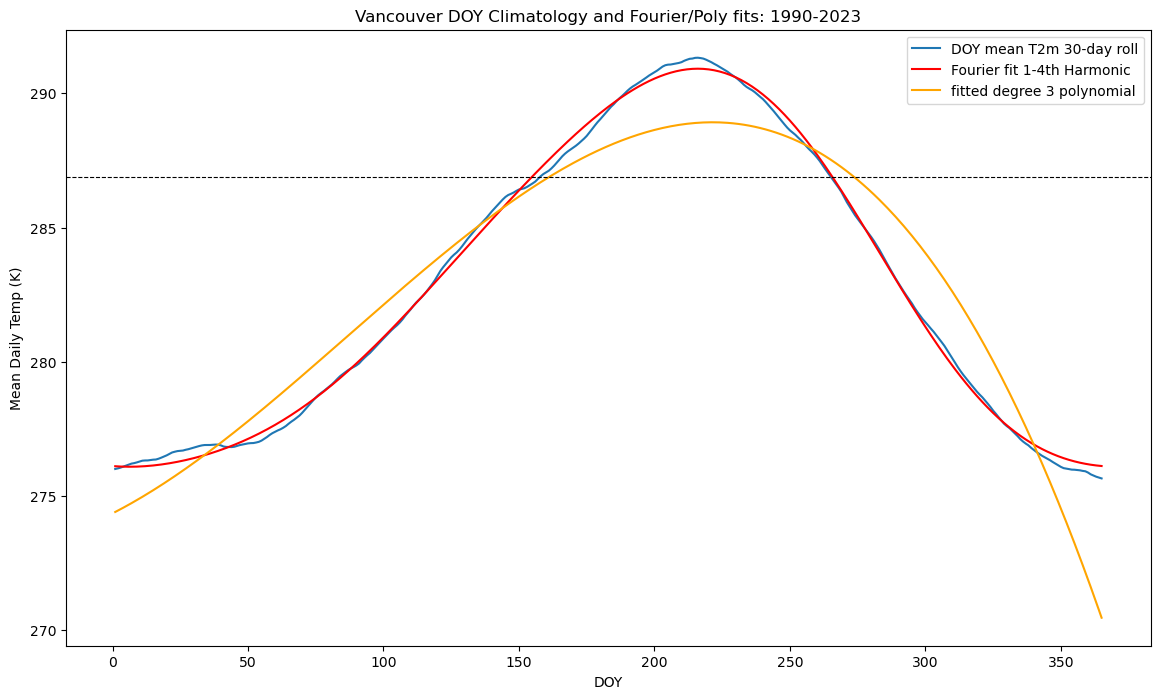

CPU times: user 90.4 ms, sys: 18 ms, total: 108 ms
Wall time: 108 ms


In [11]:
%%time

# plot the results
plt.figure(figsize=(14,8))
plt.plot(x1,y1, label='DOY mean T2m 30-day roll')
plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
plt.plot(x1, poly(x1), label='fitted degree 3 polynomial', color='orange')
plt.axhline(thresh, color="black", linewidth=0.8, linestyle="dashed")
plt.legend()
plt.xlabel('DOY')
plt.ylabel('Mean Daily Temp (K)')
#plt.xlim(130,280)
#plt.ylim(283,293)
plt.title("Vancouver DOY Climatology and Fourier/Poly fits: 1990-2023")
plt.show()

#### zoom in

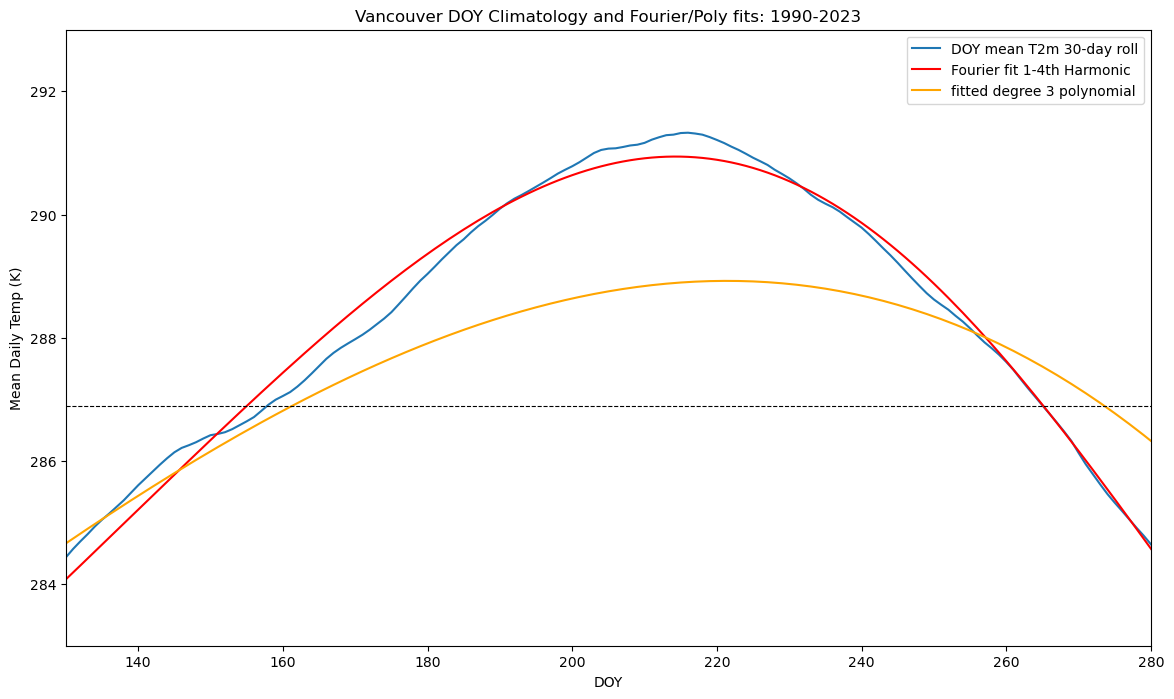

CPU times: user 96 ms, sys: 17.2 ms, total: 113 ms
Wall time: 135 ms


In [20]:
%%time

# plot the results
plt.figure(figsize=(14,8))
plt.plot(x1,y1, label='DOY mean T2m 30-day roll')
plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
plt.plot(x1, poly(x1), label='fitted degree 3 polynomial', color='orange')
plt.axhline(thresh, color="black", linewidth=0.8, linestyle="dashed")
plt.legend()
plt.xlabel('DOY')
plt.ylabel('Mean Daily Temp (K)')
plt.xlim(130,280)
plt.ylim(283,293)
plt.title("Vancouver DOY Climatology and Fourier/Poly fits: 1990-2023")
plt.show()

### Compute gradient for each for this location (Vancouver)

In [11]:
grad_t2m = np.gradient(y1)
grad_fourier = np.gradient(y_lp)
y_poly = poly(x1)
grad_poly = np.gradient(y_poly)

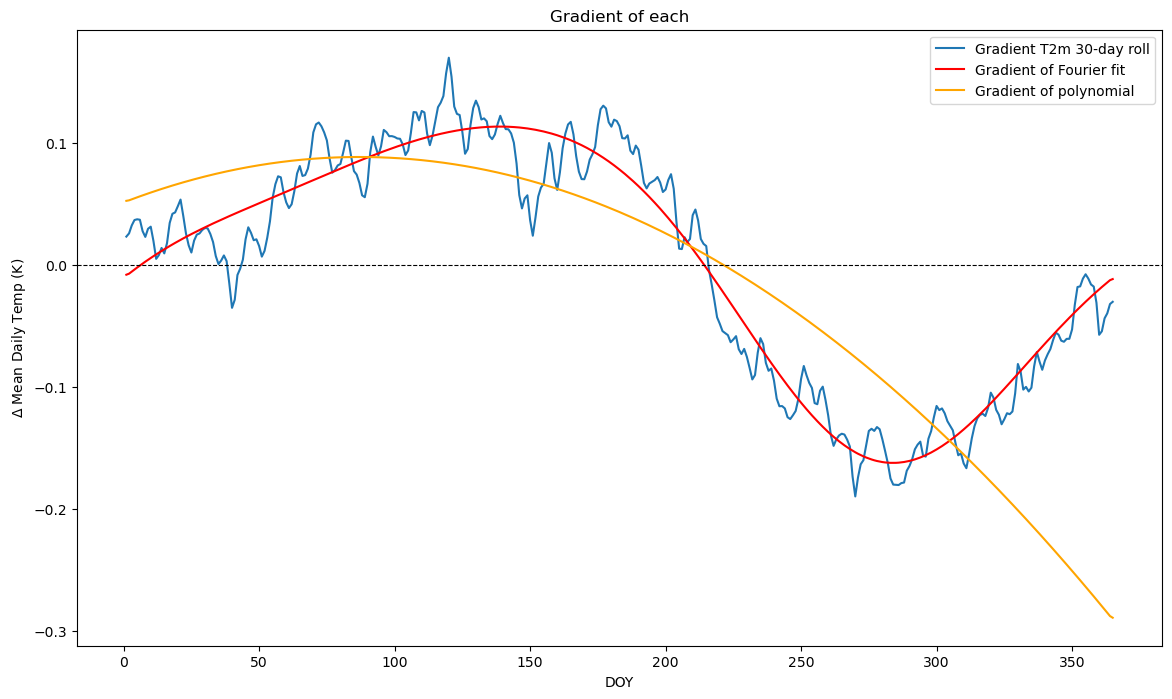

In [22]:
# plot them
plt.figure(figsize=(14,8))
plt.plot(x1,grad_t2m, label='Gradient T2m 30-day roll')
plt.plot(x_values, grad_fourier, label='Gradient of Fourier fit', color='red')
plt.plot(x1, grad_poly, label='Gradient of polynomial', color='orange')
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="dashed")
plt.legend()
plt.xlabel('DOY')
plt.ylabel('$\Delta$ Mean Daily Temp (K)')
plt.title('Gradient of each')
#plt.xlim(130,280)
# plt.ylim(283,293)
plt.show()

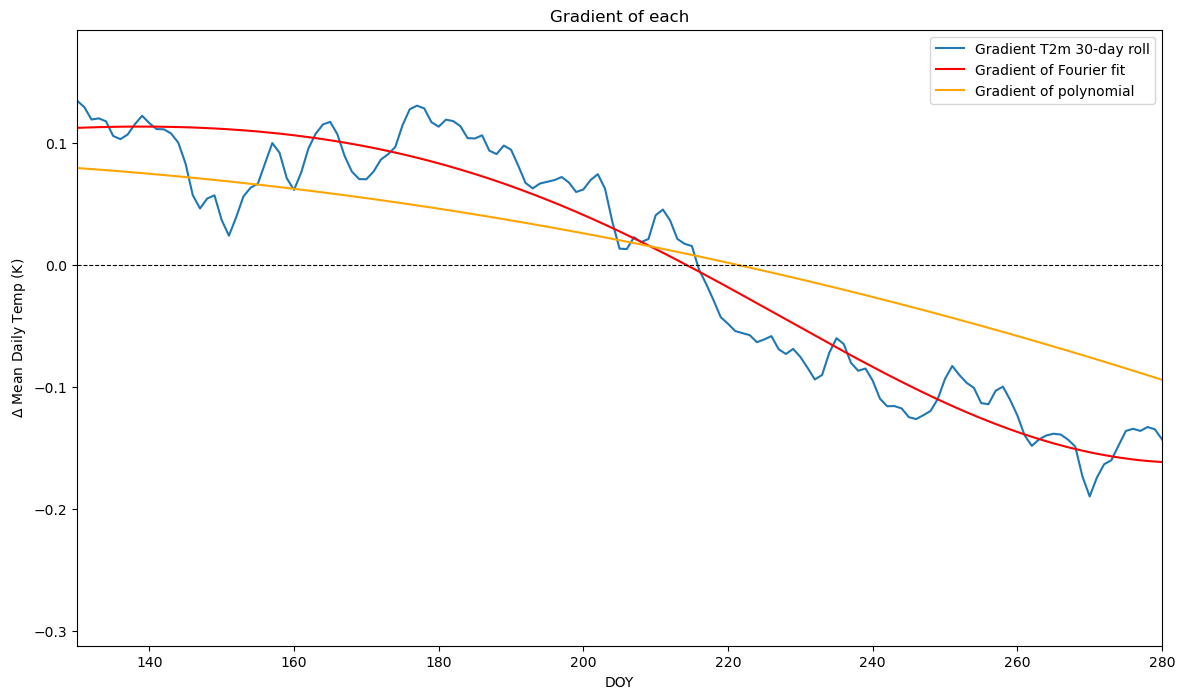

In [16]:
# plot them
plt.figure(figsize=(14,8))
plt.plot(x1,grad_t2m, label='Gradient T2m 30-day roll')
plt.plot(x_values, grad_fourier, label='Gradient of Fourier fit', color='red')
plt.plot(x1, grad_poly, label='Gradient of polynomial', color='orange')
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="dashed")
plt.legend()
plt.xlabel('DOY')
plt.ylabel('$\Delta$ Mean Daily Temp (K)')
plt.title('Gradient of each')
plt.xlim(130,280)
# plt.ylim(283,293)
plt.show()

### Should calculate and graph RMSE between gradient of Fourier and polynomial from the raw (rolling) T2m data's gradient

In [19]:
# RMSE for gradients between t2m_avg and gradient of fourier or poly fit
rmse_fourier = np.sqrt(np.sum((grad_t2m-grad_fourier)**2)/365.0)
rmse_poly = np.sqrt(np.sum((grad_t2m-grad_poly)**2)/365.0)
print("Fourier gradient RMSE = " + str(np.round(rmse_fourier, 3)) + "\n" + "Poly gradient RMSE = " + str(np.round(rmse_poly, 3)))

Fourier gradient RMSE = 0.024
Poly gradient RMSE = 0.077


### OK, need to caclulate RMSE for gradients over the DOY and also at the start/end based on the T2m DOY climatology rolling avg

In [7]:
# get size of data for building data set and also loop parameters
loop_lats = ds_full.lat.values
loop_lons = ds_full.lon.values
num_lat = loop_lats.size
num_lon = loop_lons.size
loop_lats, loop_lons, num_lat, num_lon

(array([23.5 , 23.75, 24.  , 24.25, 24.5 , 24.75, 25.  , 25.25, 25.5 ,
        25.75, 26.  , 26.25, 26.5 , 26.75, 27.  , 27.25, 27.5 , 27.75,
        28.  , 28.25, 28.5 , 28.75, 29.  , 29.25, 29.5 , 29.75, 30.  ,
        30.25, 30.5 , 30.75, 31.  , 31.25, 31.5 , 31.75, 32.  , 32.25,
        32.5 , 32.75, 33.  , 33.25, 33.5 , 33.75, 34.  , 34.25, 34.5 ,
        34.75, 35.  , 35.25, 35.5 , 35.75, 36.  , 36.25, 36.5 , 36.75,
        37.  , 37.25, 37.5 , 37.75, 38.  , 38.25, 38.5 , 38.75, 39.  ,
        39.25, 39.5 , 39.75, 40.  , 40.25, 40.5 , 40.75, 41.  , 41.25,
        41.5 , 41.75, 42.  , 42.25, 42.5 , 42.75, 43.  , 43.25, 43.5 ,
        43.75, 44.  , 44.25, 44.5 , 44.75, 45.  , 45.25, 45.5 , 45.75,
        46.  , 46.25, 46.5 , 46.75, 47.  , 47.25, 47.5 , 47.75, 48.  ,
        48.25, 48.5 , 48.75, 49.  , 49.25, 49.5 , 49.75, 50.  , 50.25,
        50.5 , 50.75, 51.  , 51.25, 51.5 , 51.75, 52.  , 52.25, 52.5 ,
        52.75, 53.  , 53.25, 53.5 , 53.75, 54.  , 54.25, 54.5 , 54.75,
      

# * Below updated to add warm months RMSE

## Compare Gradients function definition

In [20]:
# function to calculate RMSE for gradients and also the start/end DOY for each: poly, fourier, rolling avg climatology
def CompareGradients(thresh, clim_avg, show_plot):
    ''' function uses the rolling average DOY climatology data, then fits that data with a 3rd deg polynomial
    and a Fourier series up to the 4th harmonic. It then calculates the gradient of each (instantaneous derivative) using numpy's gradient func, and
    then the RMSE between the each fit and the rolling avg. Finally, it determines what the "true" start and end DOY of summer are (on avg) based on when
    the rolling avg is above the 75th percentile threshold, and calculates which DOY each fit says are the start/end. 

    These results can be analyzed for which fit model is best matching the gradient or steepness of the temp time series and also whether there is a bias
    in the start/end from each fit model relative to the climatology

    Args:
        thresh: the temperature threshold to use for determining when temps are in summer (usually the 75th percentile temperature from 1961-1990)
        clim_avg: the 30-day rolling average climatology for the grid cell over a time period (usually 1990-2023)
        show_plot: if true output a plot for that grid cell of the climatology (rolling avg) and the two fits with the "true" start/end indicated

    Returns:
        rmse_f: the rmse between the climatology 30-day rolling avg and the fourier fit
        rmse_p: the rmse between the climatology 30-day rolling avg and the polynomial fit
        rmse_summ_f: the rmse between the climatology 30-day rolling avg and the fourier fit - Apr 15 to Oct 14, inclusive
        rmse_summ_p: the rmse between the climatology 30-day rolling avg and the polynomial fit - Apr 15 to Oct 14, inclusive
        rmse_grad_f: the rmse between the gradient of the climatology's 30-day rolling avg and the fourier fit
        rmse_grad_p: the rmse between the gradient of the climatology's 30-day rolling avg and the polynomial fit
        rmse_grad_summ_f: the rmse between the gradient of the climatology's 30-day rolling avg and the fourier fit - Apr 15 to Oct 14, inclusive
        rmse_grad_summ_p: the rmse between the gradient of the climatology's 30-day rolling avg and the polynomial fit - Apr 15 to Oct 14, inclusive        
        start_clim: the start DOY based on the rolling avg climatology
        end_clim: the end DOY based on the rolling avg climatology
        start_fourier_dev: the deviation between the start of summer by fourier vs climatology (values with + means later, - means earlier)
        end_fourier_dev: the deviation between the end of summer by fourier vs climatology (values with + means later, - means earlier)
        start_poly_dev: the deviation between the start of summer by fourier vs climatology (values with + means later, - means earlier)
        end_poly_dev: the deviation between the end of summer by fourier vs climatology (values with + means later, - means earlier)
        start_grad_f: the gradient on the start of summer for the fourier fit
        end_grad_f: the gradient on the end of the summer for the fourier fit

    Example: rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)

    '''

    # set defaults
    # RMSEs for fits and gradients
    rmse_f = 0 
    rmse_summ_f = 0
    rmse_p = 0 
    rmse_summ_p = 0
    rmse_grad_f = 0 
    rmse_grad_summ_f = 0
    rmse_grad_p = 0 
    rmse_grad_summ_p = 0

    # start and end for clim avg, fourier fit, and poly fit
    start_c = 0 
    end_c = 0
    start_f = 0 
    end_f = 0
    start_p = 0 
    end_p = 0

    # deviation between start/end from clim avg and the fits
    start_f_dev = 0 
    end_f_dev = 0 
    start_p_dev = 0 
    end_p_dev = 0

    # gradients at the start and end of the summer from the fourier fit
    start_grad_f = 0
    end_grad_f = 0

    # Climatological Average
    # determine x & y for fits
    x1 = clim_avg.dayofyear.values
    y1 = clim_avg.values

    # create some x values for plotting fits
    x_values = np.linspace(min(x1), max(x1), 365)

    # for the start and end, since I am looking at the NH midlatitudes, I assume summer length will always be > 0 so 
    # I don't have the special case as many possible summers (length = 0, length = all year, double crossings of time series
    # relative to the threshold temp
    
    ### DETERMINE START AND END FOR ROLLING AVG CLIMATOLOGY
    # use fit to get stats
    summer_days = np.where(y1 >= thresh.values)[0]
    start_c = int(x_values[min(summer_days)])
    end_c = int(x_values[max(summer_days)])
    # summer length is the span between first and last + 1 to include the end day
    summer_length = end_c - start_c + 1 

    
    ### Fourier
    # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
    ymean = np.mean(y1)
    y_norm = y1 - ymean
    # perform DFT of temp data
    coef = fft(y_norm)
    # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
    # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
    Z_lp = np.copy(coef)
    Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
    # apply inverse fourier transform to convert back to time domain (just want the real part)
    y_norm_lp = np.real(np.fft.ifft(Z_lp))
    
    # add back in the original mean temp
    y_lp = y_norm_lp + ymean
    
    # RMSE for Fourier fit to the roll avg climatology
    rmse_f = np.sqrt(np.sum((y1-y_lp)**2)/365.0)

    # RMSE for 6 warmest months Apr 15 (day 105) to Oct 14 (day 287) inclusive (total 183 days)
    rmse_summ_f = np.sqrt(np.sum((y1[104:286]-y_lp[104:286])**2)/183.0)
    
    ### DETERMINE START AND END FOR FOURIER
    # use fit to get stats
    summer_days_f = np.where(y_lp >= thresh.values)[0]
    start_f = int(x_values[min(summer_days_f)])
    end_f = int(x_values[max(summer_days_f)])
    # summer length is the span between first and last + 1 to include the end day
    summer_length_f = end_f - start_f + 1 

    
    # Polynomial
    # polynomial fit, degree 3 as in Wang et al 2021
    coefs = np.polyfit(x1, y1, 3)
    poly = np.poly1d(coefs)
    y_poly = poly(x1)
    rmse_p = np.sqrt(np.sum((y1-y_poly)**2)/365.0)
    # RMSE for 6 warmest months Apr 15 (day 105) to Oct 14 (day 287) inclusive (total 183 days)
    rmse_summ_p = np.sqrt(np.sum((y1[104:286]-y_poly[104:286])**2)/183.0)

    ### DETERMINE START AND END FOR POLYNOMIAL
    # use fit to get stats
    summer_days_p = np.where(y_poly >= thresh.values)[0]

    # handle case where polynomial says no summer in fit (doesn't seem to be a problem for Fourier fit)
    if np.count_nonzero(y_poly >= thresh.values) == 0:
        start_p = 0
        end_p = 0
        summer_length_p = 0
        print("This location: "+str(clim_avg.lat.values)+","+str(clim_avg.lon.values)+" has no summer in poly fit")
    else:
        start_p = int(x_values[min(summer_days_p)])
        end_p = int(x_values[max(summer_days_p)])
        # summer length is the span between first and last + 1 to include the end day
        summer_length_p = end_p - start_p + 1 

  
    ####################
    # CALCULATE THE DEVIATIONSS
    ####################
    # deviation between start/end from clim avg and the fits
    start_f_dev = start_f - start_c 
    end_f_dev = end_f - end_c 
    start_p_dev = start_p - start_c 
    end_p_dev = end_p - end_c

    ### Calculate gradients
    grad_t2m = np.gradient(y1)
    grad_fourier = np.gradient(y_lp)
    grad_poly = np.gradient(y_poly)

    start_grad_f = grad_fourier[start_c+1]
    end_grad_f = grad_fourier[end_c+1]

    # RMSE for gradients between t2m_avg and gradient of fourier or poly fit
    rmse_grad_f = np.sqrt(np.sum((grad_t2m-grad_fourier)**2)/365.0)
    rmse_grad_p = np.sqrt(np.sum((grad_t2m-grad_poly)**2)/365.0)
    # RMSE for 6 warmest months Apr 15 (day 105) to Oct 14 (day 287) inclusive (total 183 days)
    rmse_grad_summ_f = np.sqrt(np.sum((grad_t2m[104:286]-grad_fourier[104:286])**2)/183.0)
    # RMSE for 6 warmest months Apr 15 (day 105) to Oct 14 (day 287) inclusive (total 183 days)
    rmse_grad_summ_p = np.sqrt(np.sum((grad_t2m[104:286]-grad_poly[104:286])**2)/183.0)
    
    #print("Fourier gradient RMSE = " + str(np.round(rmse_fourier, 3)) + "\n" + "Poly gradient RMSE = " + str(np.round(rmse_poly, 3)))
    
    
    # make and save plot if desired
    ##
    ##
    if show_plot:
        # print summer stats from each
        print("Clim Avg says start is day "+str(start_c)+" and end is day "+str(end_c)+" and length is "+str(summer_length))
        print("Fourier fit says start is day "+str(start_f)+" and end is day "+str(end_f)+" and length is "+str(summer_length_f))
        print("Fourier fit says start is day "+str(start_p)+" and end is day "+str(end_p)+" and length is "+str(summer_length_p))
        print("Gradient of Fourier Fit at clim start: "+str(start_grad_f)+" and at clim end: "+str(end_grad_f))

        # get lat and lon for plot title
        cell_lat = clim_avg.lat.values
        cell_lon = clim_avg.lon.values
        
        plt.figure(figsize=(12,10))

        # temp vs doy plot
        plt.subplot(211)
        plt.plot(x1,y1, label='DOY mean T2m 30-day roll')
        plt.plot(x1, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.plot(x1, y_poly, label='fitted degree 3 polynomial', color='orange')
        plt.axhline(thresh, color="black", linewidth=0.8, linestyle="dashed")

        plt.xlabel('DOY')
        plt.ylabel('Mean Daily Temp (K)')

        # start and end of climatological average summer
        plt.axvline(start_c, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(end_c, color="black", linewidth=0.8, linestyle="dashed")

        # add dashed lines for start & end from fits
        plt.axvline(start_f, color="red", linewidth=0.8, linestyle="dashed")
        plt.axvline(end_f, color="red", linewidth=0.8, linestyle="dashed")
        plt.axvline(start_p, color="orange", linewidth=0.8, linestyle="dashed")
        plt.axvline(end_p, color="orange", linewidth=0.8, linestyle="dashed")
        
        plt.annotate('start', xy=(start_c-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(end_c-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('Clim summer = '+str(summer_length)+' days', xy=(start_c+5,np.mean(y1)), fontsize=15)
        plt.annotate('75th percentile = '+str(np.round(thresh.values,1))+'K', xy=(0,thresh.values-1), fontsize=18)
        #plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        #plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)
        plt.title("Climatological (1990-2023) Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()

        # gradient of each vs doy plot
        plt.subplot(212)
        plt.plot(x1,grad_t2m, label='Gradient T2m 30-day roll')
        plt.plot(x_values, grad_fourier, label='Gradient of Fourier fit', color='red')
        plt.plot(x1, grad_poly, label='Gradient of polynomial', color='orange')
        plt.axhline(0.0, color="black", linewidth=0.8, linestyle="dashed")
        # start and end of climatological average summer
        plt.axvline(start_c, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(end_c, color="black", linewidth=0.8, linestyle="dashed")
        
        plt.legend()
        plt.xlabel('DOY')
        plt.ylabel('$\Delta$ Mean Daily Temp (K)')
        plt.title('Gradient of each')
        #plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.tight_layout()
        plt.show()
        
    

    # returns
    return float(rmse_f), float(rmse_p), float(rmse_summ_f), float(rmse_summ_p), float(rmse_grad_f), float(rmse_grad_p), float(rmse_grad_summ_f), float(rmse_grad_summ_p), int(start_c), int(end_c), int(start_f_dev), int(end_f_dev), int(start_p_dev), int(end_p_dev), float(start_grad_f), float(end_grad_f)



### test function for Vancouver

Clim Avg says start is day 158 and end is day 265 and length is 108
Fourier fit says start is day 155 and end is day 265 and length is 111
Fourier fit says start is day 162 and end is day 273 and length is 112
Gradient of Fourier Fit at clim start: 0.100997925 and at clim end: -0.15383911


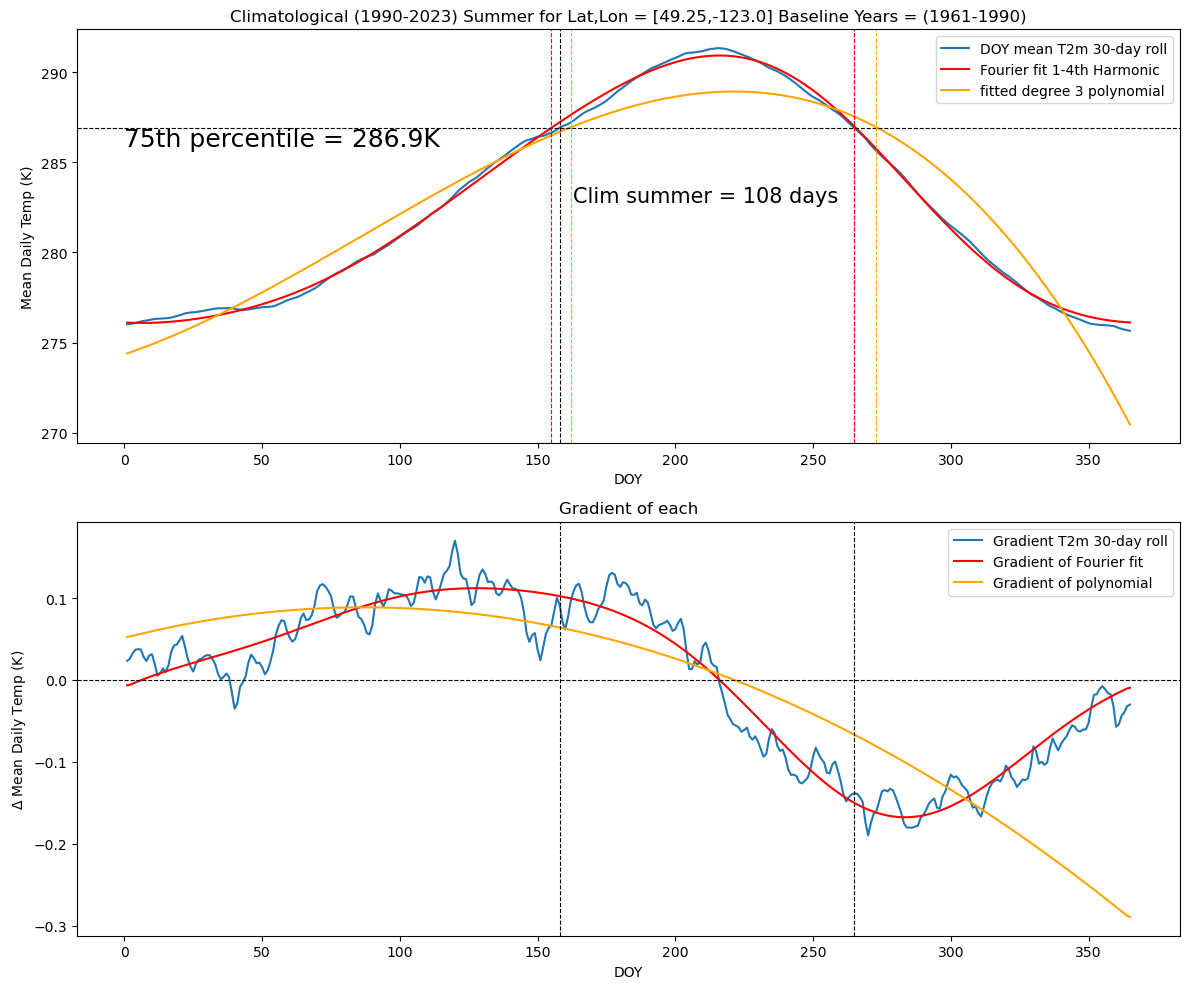

(0.23241457343101501,
 1.564183658447689,
 0.24069122970104218,
 1.3019727122133555,
 0.023981912061572075,
 0.07706921854607288,
 0.02557583525776863,
 0.05273692657311015,
 158,
 265,
 -3,
 0,
 4,
 8,
 0.1009979248046875,
 -0.153839111328125)

In [21]:
# test it for Vancouver of course
input_lat = 49.246
input_lon = -123.116

thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

array(49.25)

### Test a location in the North Atlantic Ocean

Clim Avg says start is day 178 and end is day 279 and length is 102
Fourier fit says start is day 178 and end is day 279 and length is 102
Fourier fit says start is day 187 and end is day 296 and length is 110
Gradient of Fourier Fit at clim start: 0.06352234 and at clim end: -0.067352295


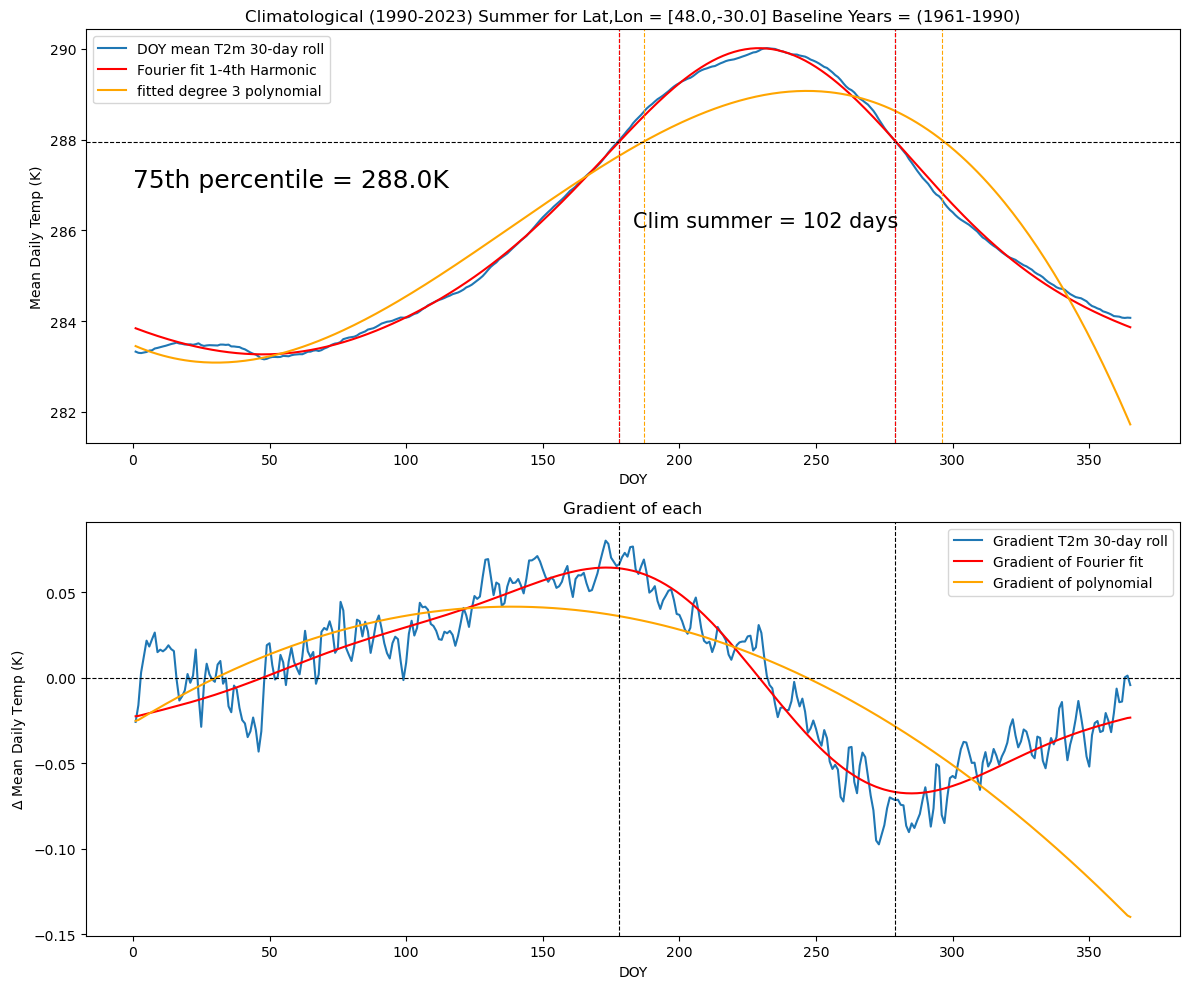

(0.11096134036779404,
 0.7183355370593993,
 0.07998839765787125,
 0.6459974300911447,
 0.013916684314608574,
 0.037349422843325514,
 0.011317082680761814,
 0.027227430867988,
 178,
 279,
 0,
 0,
 9,
 17,
 0.0635223388671875,
 -0.067352294921875)

In [22]:
# test it for Vancouver of course
input_lat = 48
input_lon = -30

thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

### Test a location in the North Pacific Ocean

Clim Avg says start is day 186 and end is day 288 and length is 103
Fourier fit says start is day 185 and end is day 289 and length is 105
Fourier fit says start is day 187 and end is day 310 and length is 124
Gradient of Fourier Fit at clim start: 0.11819458 and at clim end: -0.09677124


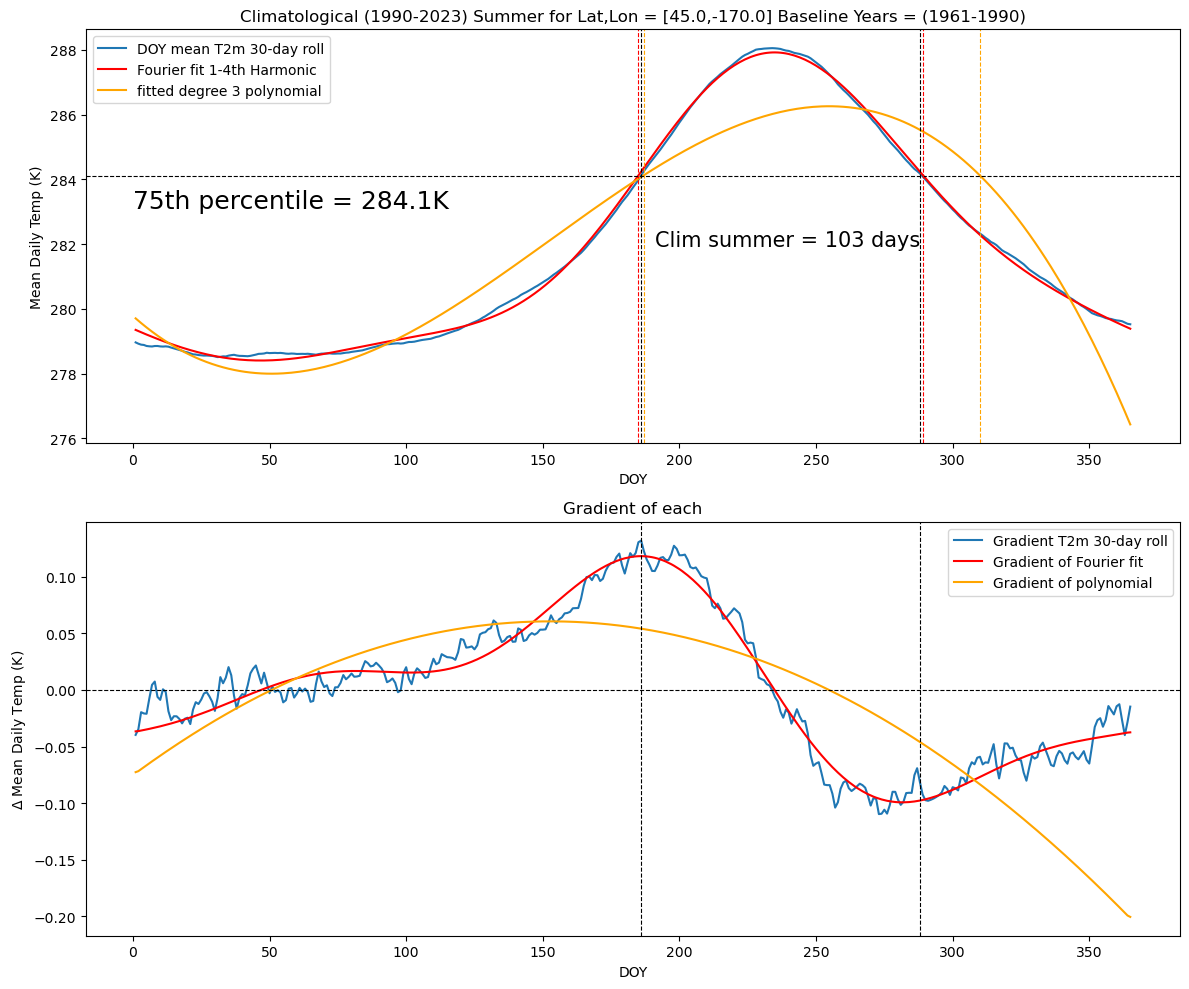

(0.12563028931617737,
 1.1049248115465822,
 0.12117419391870499,
 1.1708162279039207,
 0.012692553922533989,
 0.055172793094122916,
 0.011703156866133213,
 0.04866759230656775,
 186,
 288,
 -1,
 1,
 1,
 22,
 0.118194580078125,
 -0.096771240234375)

In [23]:
# test it 
input_lat = 45
input_lon = -170

thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

### Test a location in the Pacific Ocean just West of California where the RMSE map says poly and fourier should be closer

Clim Avg says start is day 193 and end is day 299 and length is 107
Fourier fit says start is day 193 and end is day 298 and length is 106
Fourier fit says start is day 200 and end is day 313 and length is 114
Gradient of Fourier Fit at clim start: 0.06864929 and at clim end: -0.07292175


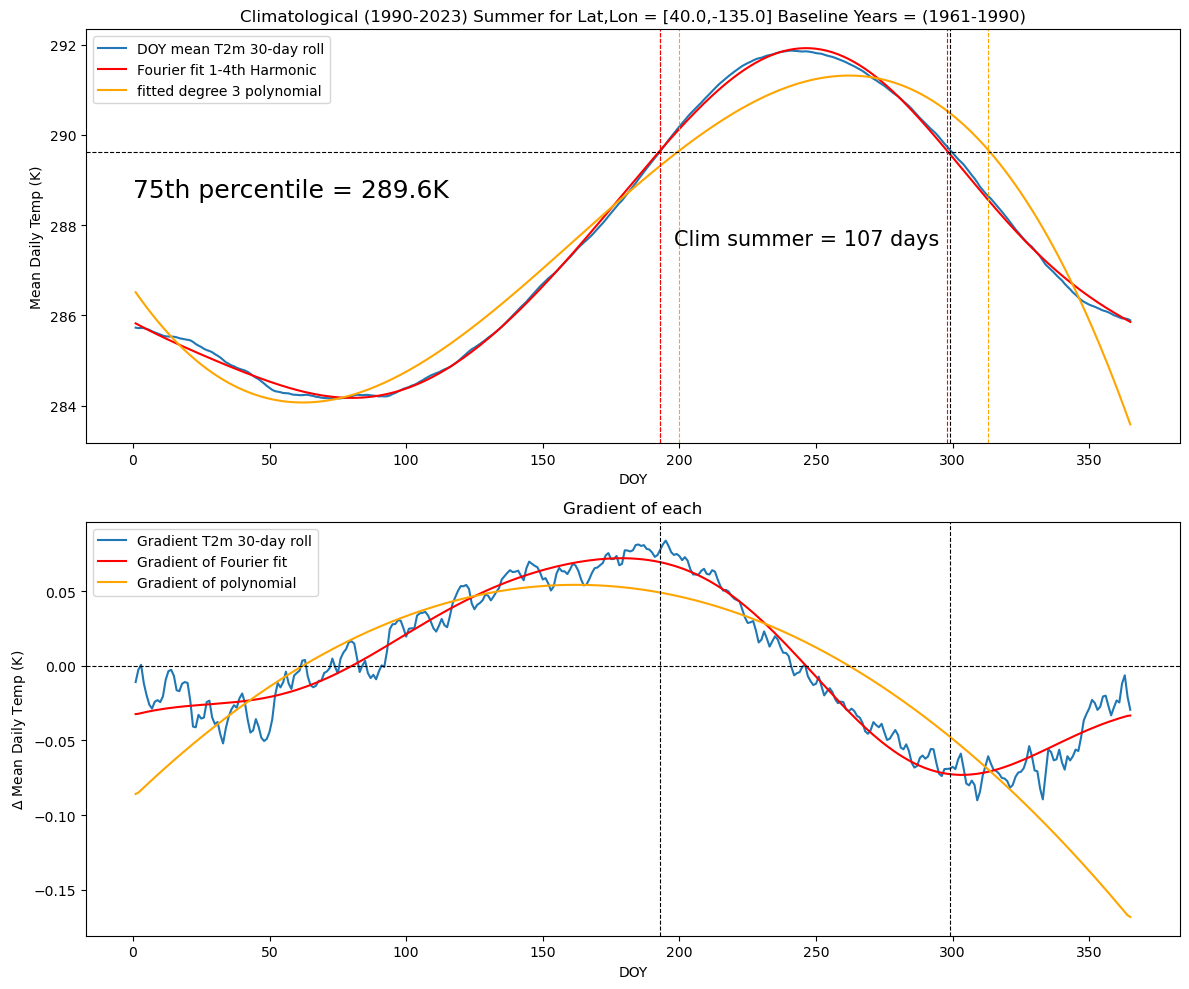

(0.08217193186283112,
 0.5938806869213622,
 0.06706281006336212,
 0.5156492277918506,
 0.010171184316277504,
 0.037782379651106486,
 0.006962741259485483,
 0.01964391146701003,
 193,
 299,
 0,
 -1,
 7,
 14,
 0.0686492919921875,
 -0.0729217529296875)

In [24]:
# test it 
input_lat = 40
input_lon = -135

thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

## Use function and loop over all grid points

In [25]:
%%time

# takes 6 min for NH

# empty data arrays for stats
rmse_fourier = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_poly = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_summ_fourier = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_summ_poly = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_grad_fourier = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_grad_poly = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_grad_summ_fourier = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

rmse_grad_summ_poly = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

start_clim = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

end_clim = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

start_fourier_dev = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

end_fourier_dev = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

start_poly_dev = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

end_poly_dev = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

start_grad_f = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

end_grad_f = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
rmse_fourier.attrs["long_name"] = "RMSE between Fourier Fit and Rolling Avg Climatology"
rmse_fourier.attrs["units"] = "Degrees [K]"
rmse_poly.attrs["long_name"] = "RMSE between Polynomial Fit and Rolling Avg Climatology"
rmse_poly.attrs["units"] = "Degrees [K]"

rmse_summ_fourier.attrs["long_name"] = "RMSE between Fourier Fit and Rolling Avg Climatology Apr 15 - Oct 14"
rmse_summ_fourier.attrs["units"] = "Degrees [K]"
rmse_summ_poly.attrs["long_name"] = "RMSE between Polynomial Fit and Rolling Avg Climatology Apr 15 - Oct 14"
rmse_summ_poly.attrs["units"] = "Degrees [K]"

rmse_grad_fourier.attrs["long_name"] = "RMSE between Gradient by DOY of Fourier Fit and Rolling Avg Climatology"
rmse_grad_fourier.attrs["units"] = "Delta K / Day"
rmse_grad_poly.attrs["long_name"] = "RMSE between Gradient by DOY of Polynomial Fit and Rolling Avg Climatology"
rmse_grad_poly.attrs["units"] = "Delta K / Day"

rmse_grad_summ_fourier.attrs["long_name"] = "RMSE between Gradient by DOY of Fourier Fit and Rolling Avg Climatology Apr 15 - Oct 14"
rmse_grad_summ_fourier.attrs["units"] = "Delta K / Day"
rmse_grad_summ_poly.attrs["long_name"] = "RMSE between Gradient by DOY of Polynomial Fit and Rolling Avg Climatology Apr 15 - Oct 14"
rmse_grad_summ_poly.attrs["units"] = "Delta K / Day"

start_clim.attrs["long_name"] = "Start DOY based on Rolling Avg Climatology"
start_clim.attrs["units"] = "DOY"
end_clim.attrs["long_name"] = "End DOY based on Rolling Avg Climatology"
end_clim.attrs["units"] = "DOY"

start_fourier_dev.attrs["long_name"] = "Deviation of DOY of Summer Start from Fourier Fit vs Rolling Avg Climatology"
start_fourier_dev.attrs["units"] = "Days"
end_fourier_dev.attrs["long_name"] = "Deviation of DOY of Summer End from Fourier Fit vs Rolling Avg Climatology"
end_fourier_dev.attrs["units"] = "Days"

start_poly_dev.attrs["long_name"] = "Deviation of DOY of Summer Start from Polynomial Fit vs Rolling Avg Climatology"
start_poly_dev.attrs["units"] = "Days"
end_poly_dev.attrs["long_name"] = "Deviation of DOY of Summer End from Polynomial Fit vs Rolling Avg Climatology"
end_poly_dev.attrs["units"] = "Days"

start_grad_f.attrs["long_name"] = "Gradient of Fourier Fit at Summer Start according to Rolling Avg Climatology"
start_grad_f.attrs["units"] = "Deg/Day"
end_grad_f.attrs["long_name"] = "Gradient of Fourier Fit at Summer End according to Rolling Avg Climatology"
end_grad_f.attrs["units"] = "Deg/Day"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:
        # get threshold from c_75 for that location
        thresh = c_75.sel(lat=input_lat,lon=input_lon)

        # get the 30-day rolling avg climatology for that location
        clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon)

        # build gradient stats for the grid cell and produce the plot if desired (currently False)
        rmse_f, rmse_p, rmse_summ_f, rmse_summ_p, rmse_grad_f, rmse_grad_p, rmse_grad_summ_f, rmse_grad_summ_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_gr_f, end_gr_f = CompareGradients(thresh, clim_avg, False)
        
        # xarray requires strange indexing in order to replace values by coordinate
        rmse_fourier.loc[input_lat, input_lon] = rmse_f
        rmse_poly.loc[input_lat, input_lon] = rmse_p
        rmse_grad_fourier.loc[input_lat, input_lon] = rmse_grad_f
        rmse_grad_poly.loc[input_lat, input_lon] = rmse_grad_p

        rmse_summ_fourier.loc[input_lat, input_lon] = rmse_summ_f
        rmse_summ_poly.loc[input_lat, input_lon] = rmse_summ_p
        rmse_grad_summ_fourier.loc[input_lat, input_lon] = rmse_grad_summ_f
        rmse_grad_summ_poly.loc[input_lat, input_lon] = rmse_grad_summ_p
        
        start_clim.loc[input_lat, input_lon] = start
        end_clim.loc[input_lat, input_lon] = end
        start_fourier_dev.loc[input_lat, input_lon] = start_f_dev
        end_fourier_dev.loc[input_lat, input_lon] = end_f_dev
        start_poly_dev.loc[input_lat, input_lon] = start_p_dev
        end_poly_dev.loc[input_lat, input_lon] = end_p_dev
        start_grad_f.loc[input_lat, input_lon] = start_gr_f
        end_grad_f.loc[input_lat, input_lon] = end_gr_f
        


# save it out
grad_ds = xr.Dataset(data_vars={'RMSEFourier':rmse_fourier,
                           'RMSEPoly':rmse_poly,
                            'RMSE_Summ_Fourier':rmse_summ_fourier,
                           'RMSE_Summ_Poly':rmse_summ_poly,
                           'RMSEGradFourier':rmse_grad_fourier,
                           'RMSEGradPoly':rmse_grad_poly,
                            'RMSEGrad_Summ_Fourier':rmse_grad_summ_fourier,
                           'RMSEGrad_Summ_Poly':rmse_grad_summ_poly,
                           'ClimAvgStartDOY':start_clim,
                           'ClimAvgEndDOY':end_clim,
                           'StartDeviationFourier':start_fourier_dev,
                           'EndDeviationFourier':end_fourier_dev,
                           'StartDeviationPoly':start_poly_dev,
                            'EndDeviationPoly':end_poly_dev,
                            'GradientSummStartFourier':start_grad_f,
                            'GradientSummEndFourier':end_grad_f})

# how does it look
grad_ds

This location: 61.75,-47.75 has no summer in poly fit
This location: 62.0,-47.75 has no summer in poly fit
This location: 62.25,-48.5 has no summer in poly fit
This location: 62.25,-48.25 has no summer in poly fit
This location: 62.25,-48.0 has no summer in poly fit
This location: 64.5,-49.25 has no summer in poly fit
This location: 66.0,-51.75 has no summer in poly fit
This location: 66.0,-51.5 has no summer in poly fit
This location: 66.0,-51.25 has no summer in poly fit
This location: 69.25,-49.5 has no summer in poly fit
CPU times: user 5min 48s, sys: 1.26 s, total: 5min 49s
Wall time: 5min 50s


<xarray.Dataset> Size: 34MB
Dimensions:                   (lat: 187, lon: 1440)
Coordinates:
  * lat                       (lat) float64 1kB 23.5 23.75 24.0 ... 69.75 70.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables: (12/16)
    RMSEFourier               (lat, lon) float64 2MB 0.1123 0.1119 ... 0.37
    RMSEPoly                  (lat, lon) float64 2MB 0.3222 0.3229 ... 2.054
    RMSE_Summ_Fourier         (lat, lon) float64 2MB 0.1286 0.1283 ... 0.3817
    RMSE_Summ_Poly            (lat, lon) float64 2MB 0.2872 0.2876 ... 1.79
    RMSEGradFourier           (lat, lon) float64 2MB 0.009697 ... 0.03391
    RMSEGradPoly              (lat, lon) float64 2MB 0.01878 0.01878 ... 0.11
    ...                        ...
    StartDeviationFourier     (lat, lon) float64 2MB 7.0 7.0 7.0 ... 3.0 3.0 2.0
    EndDeviationFourier       (lat, lon) float64 2MB 3.0 3.0 3.0 ... 3.0 3.0 3.0
    StartDeviationPoly        (lat, lon) float64 2MB 23.0 23.0 ... 30.0 29.0
    EndDeviationPoly          (lat, lon) float64 2MB 13.0 13.0 13.0 ... 7.0 7.0
    GradientSummStartFourier  (lat, lon) float64 2MB 0.03079 0.03087 ... 0.1577
    GradientSummEndFourier    (lat, lon) float64 2MB -0.03394 ... -0.127

## Based on initial tests, there are some locations where the polynomial fit yields NO summer even though the clim avg and fourier say there is a summer. So, I will get very large negative values for both start and end for the start_poly_dev and end_poly_dev - will need to sort those out

### Because I know I will want them, adding in the lsm and coastal flags before writing out

In [26]:
# get lsm
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
#ds_lsm
ds_lsm_nh = ds_lsm.sel(lat=slice(nh_max, nh_min))
ds_lsm_nh


<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 187, lon: 1440)
Coordinates:
  * lat      (lat) float32 748B 70.0 69.75 69.5 69.25 ... 24.25 24.0 23.75 23.5
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 2MB ...

In [27]:
# get coastal margins
input_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
ds_coastal = xr.open_dataset(input_path)
ds_coastal_nh = ds_coastal.sel(lat=slice(nh_max, nh_min))
ds_coastal_nh

<xarray.Dataset> Size: 276kB
Dimensions:  (lat: 187, lon: 1440)
Coordinates:
  * lat      (lat) float32 748B 70.0 69.75 69.5 69.25 ... 24.25 24.0 23.75 23.5
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 269kB ...

In [28]:
# merge all data together
grad_ds_temp = grad_ds.merge(ds_lsm_nh)
grad_ds_temp = grad_ds_temp.merge(ds_coastal_nh)
grad_ds_temp

<xarray.Dataset> Size: 37MB
Dimensions:                   (lat: 187, lon: 1440)
Coordinates:
  * lat                       (lat) float64 1kB 23.5 23.75 24.0 ... 69.75 70.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables: (12/18)
    RMSEFourier               (lat, lon) float64 2MB 0.1123 0.1119 ... 0.37
    RMSEPoly                  (lat, lon) float64 2MB 0.3222 0.3229 ... 2.054
    RMSE_Summ_Fourier         (lat, lon) float64 2MB 0.1286 0.1283 ... 0.3817
    RMSE_Summ_Poly            (lat, lon) float64 2MB 0.2872 0.2876 ... 1.79
    RMSEGradFourier           (lat, lon) float64 2MB 0.009697 ... 0.03391
    RMSEGradPoly              (lat, lon) float64 2MB 0.01878 0.01878 ... 0.11
    ...                        ...
    StartDeviationPoly        (lat, lon) float64 2MB 23.0 23.0 ... 30.0 29.0
    EndDeviationPoly          (lat, lon) float64 2MB 13.0 13.0 13.0 ... 7.0 7.0
    GradientSummStartFourier  (lat, lon) float64 2MB 0.03079 0.03087 ... 0.1577
    GradientSummEndFourier    (lat, lon) float64 2MB -0.03394 ... -0.127
    lsm                       (lat, lon) float64 2MB ...
    Coastal                   (lat, lon) bool 269kB ...

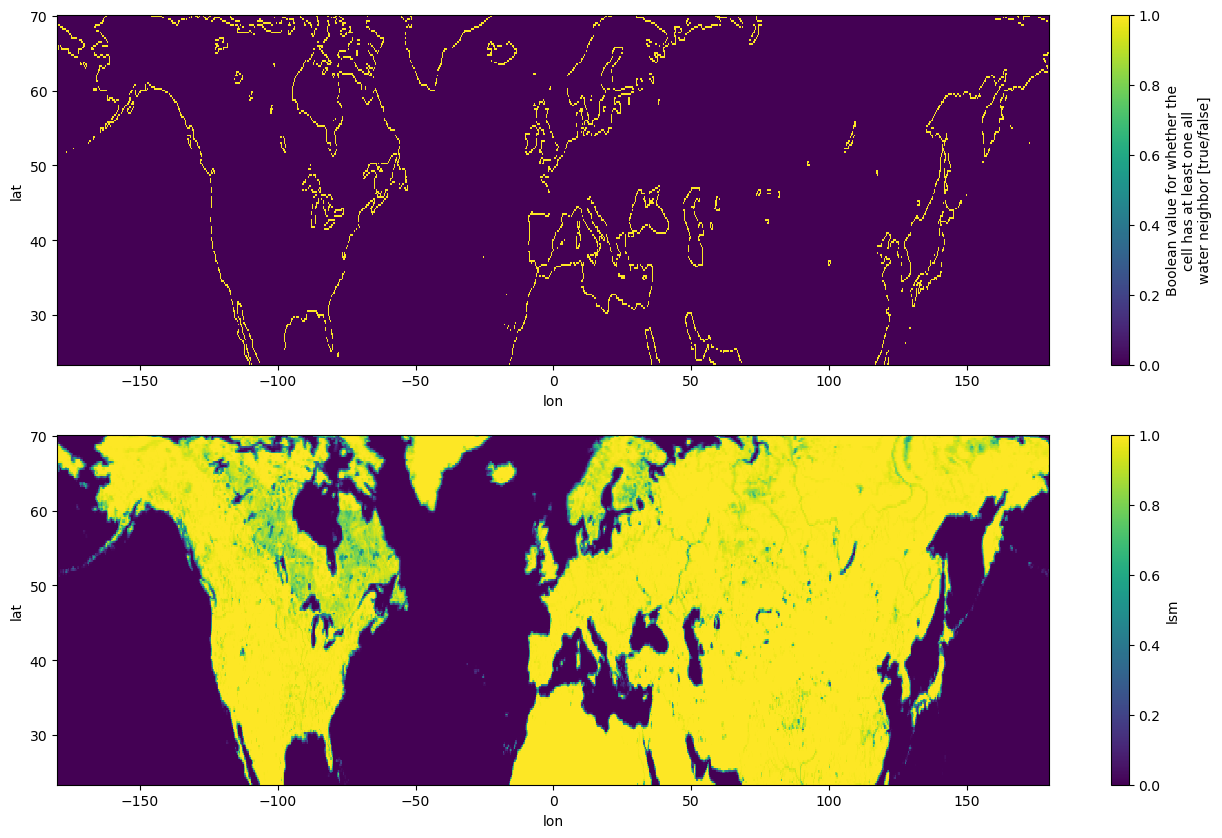

<Figure size 640x480 with 0 Axes>

In [29]:
# plot to make sure it looks right
#
plt.figure(figsize=(16,10))
plt.subplot(211)
grad_ds_temp.Coastal.plot()
plt.subplot(212)
grad_ds_temp.lsm.plot()
plt.show()
plt.tight_layout()

## Write out the results

In [30]:
output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1990-2023_NH_gradient_stats.nc'
grad_ds_temp.to_netcdf(output_path)

### Read them back in

In [31]:
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1990-2023_NH_gradient_stats.nc'
grad_ds_temp = xr.open_dataset(input_path)
grad_ds_temp

<xarray.Dataset> Size: 37MB
Dimensions:                   (lat: 187, lon: 1440)
Coordinates:
  * lat                       (lat) float64 1kB 23.5 23.75 24.0 ... 69.75 70.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables: (12/18)
    RMSEFourier               (lat, lon) float64 2MB ...
    RMSEPoly                  (lat, lon) float64 2MB ...
    RMSE_Summ_Fourier         (lat, lon) float64 2MB ...
    RMSE_Summ_Poly            (lat, lon) float64 2MB ...
    RMSEGradFourier           (lat, lon) float64 2MB ...
    RMSEGradPoly              (lat, lon) float64 2MB ...
    ...                        ...
    StartDeviationPoly        (lat, lon) float64 2MB ...
    EndDeviationPoly          (lat, lon) float64 2MB ...
    GradientSummStartFourier  (lat, lon) float64 2MB ...
    GradientSummEndFourier    (lat, lon) float64 2MB ...
    lsm                       (lat, lon) float64 2MB ...
    Coastal                   (lat, lon) bool 269kB ...

## What about one of the spots with NO SUMMER from the poly fit?

This location: 62.0,-47.75 has no summer in poly fit
Clim Avg says start is day 160 and end is day 239 and length is 80
Fourier fit says start is day 158 and end is day 237 and length is 80
Fourier fit says start is day 0 and end is day 0 and length is 0
Gradient of Fourier Fit at clim start: 0.09257507 and at clim end: -0.100234985


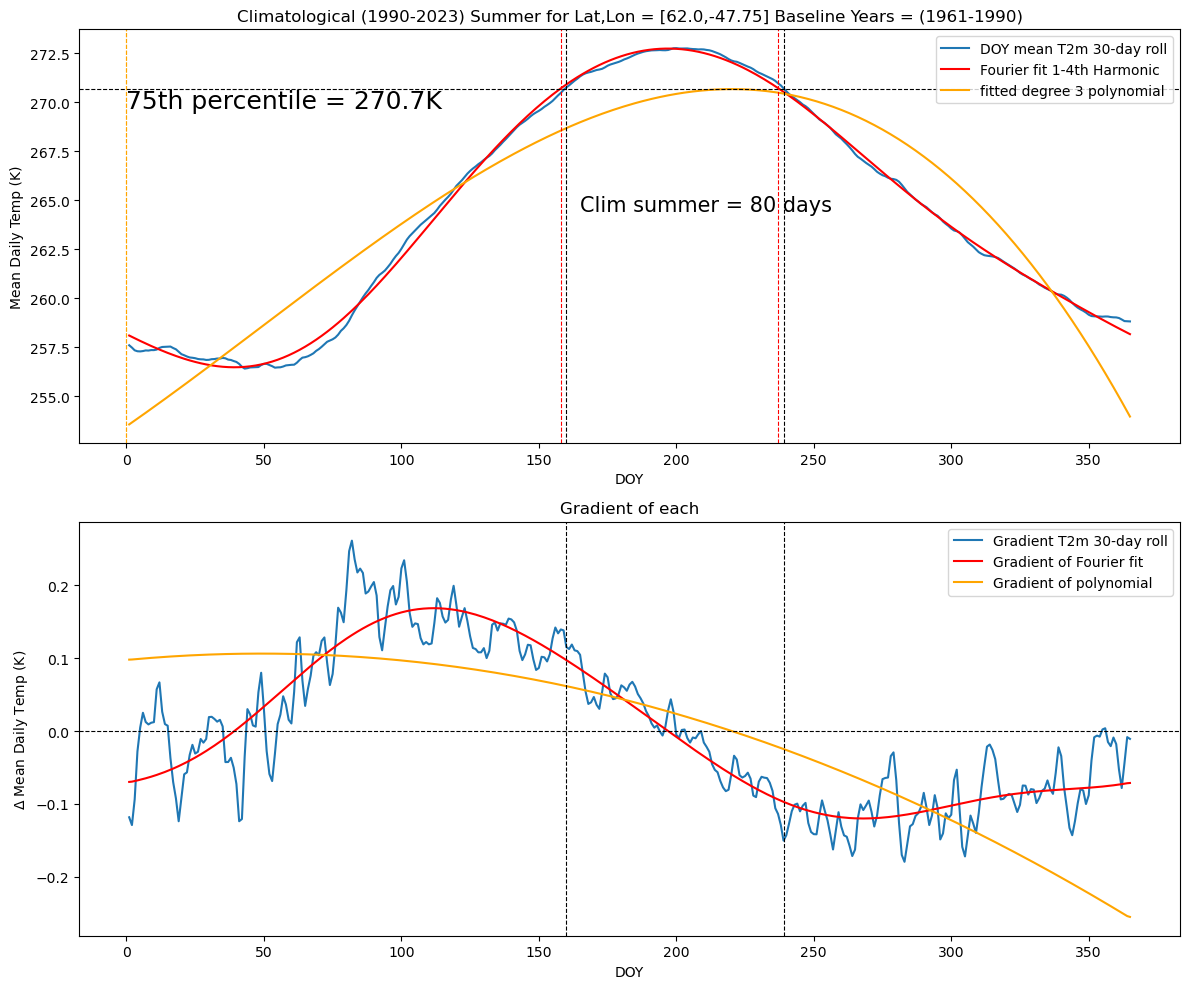

(0.2656686305999756,
 2.0324587364332394,
 0.039114851504564285,
 0.09210154391402689,
 160,
 239,
 -2,
 -2,
 -160,
 -239,
 0.0925750732421875,
 -0.1002349853515625)

In [24]:
# # test one of those spots that had "no summer" for poly fit

# # test it 
# input_lat = 62.0
# input_lon = -47.75

# thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
# clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
# rmse_f, rmse_p, rmse_grad_f, rmse_grad_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
# rmse_f, rmse_p, rmse_grad_f, rmse_grad_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

This location: 66.0,-51.5 has no summer in poly fit
Clim Avg says start is day 158 and end is day 241 and length is 84
Fourier fit says start is day 158 and end is day 236 and length is 79
Fourier fit says start is day 0 and end is day 0 and length is 0
Gradient of Fourier Fit at clim start: 0.11691284 and at clim end: -0.11149597


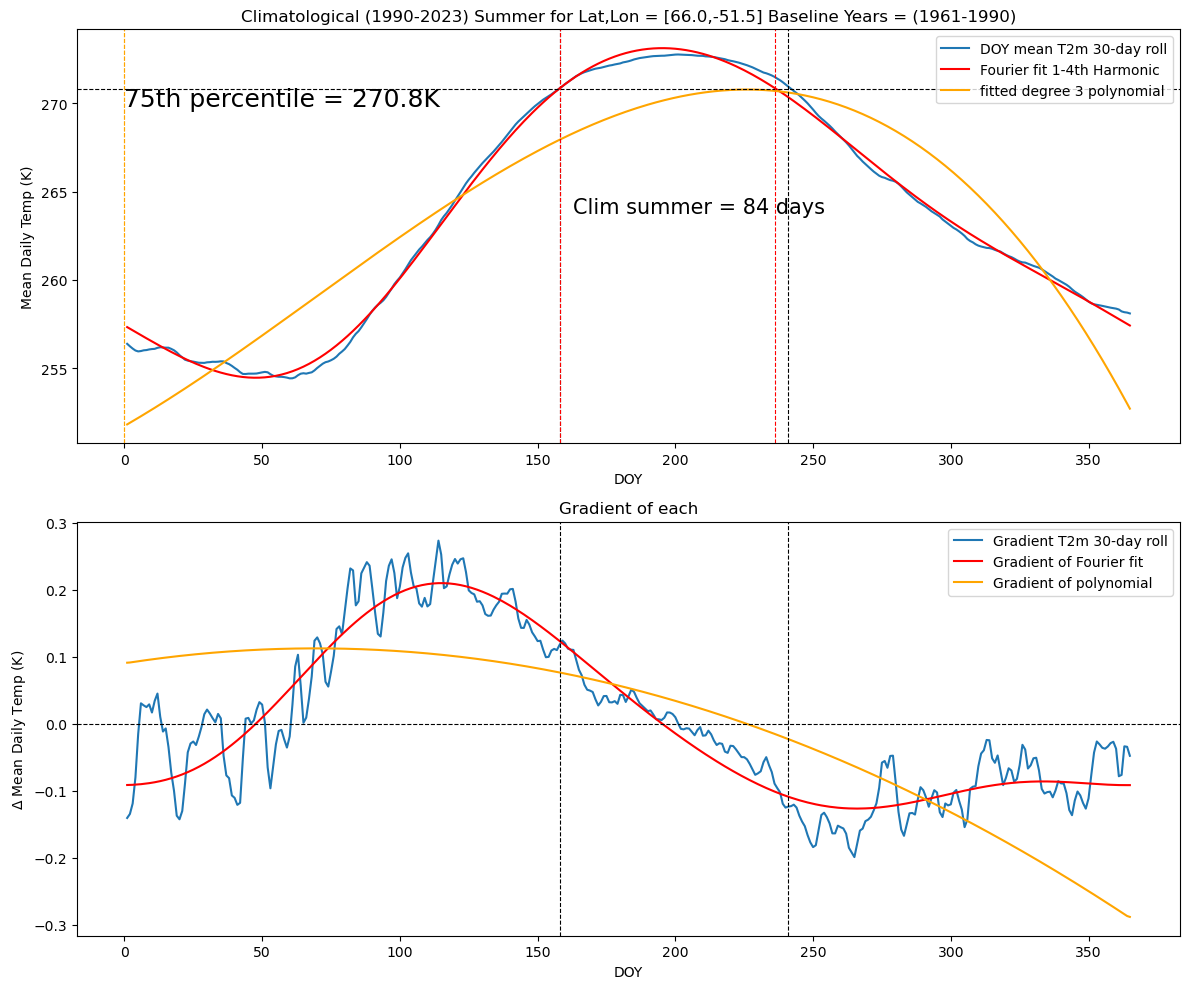

(0.34452539682388306,
 2.5067786252687085,
 0.040788207203149796,
 0.10536092013774133,
 158,
 241,
 0,
 -5,
 -158,
 -241,
 0.116912841796875,
 -0.1114959716796875)

In [25]:
# # one more
# # test one of those spots that had "no summer" for poly fit

# # test it 
# input_lat = 66.0
# input_lon = -51.5

# thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
# clim_avg = ds_daily_clim_30dayroll2.sel(lat=input_lat, lon=input_lon, method='nearest')
# rmse_f, rmse_p, rmse_grad_f, rmse_grad_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f = CompareGradients(thresh, clim_avg, True)
# rmse_f, rmse_p, rmse_grad_f, rmse_grad_p, start, end, start_f_dev, end_f_dev, start_p_dev, end_p_dev, start_grad_f, end_grad_f

## Plot each variable as a map

In [32]:
plot_vars = list(grad_ds_temp.data_vars)
remove_me = {'lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['RMSEFourier',
 'RMSEPoly',
 'RMSE_Summ_Fourier',
 'RMSE_Summ_Poly',
 'RMSEGradFourier',
 'RMSEGradPoly',
 'RMSEGrad_Summ_Fourier',
 'RMSEGrad_Summ_Poly',
 'ClimAvgStartDOY',
 'ClimAvgEndDOY',
 'StartDeviationFourier',
 'EndDeviationFourier',
 'StartDeviationPoly',
 'EndDeviationPoly',
 'GradientSummStartFourier',
 'GradientSummEndFourier']

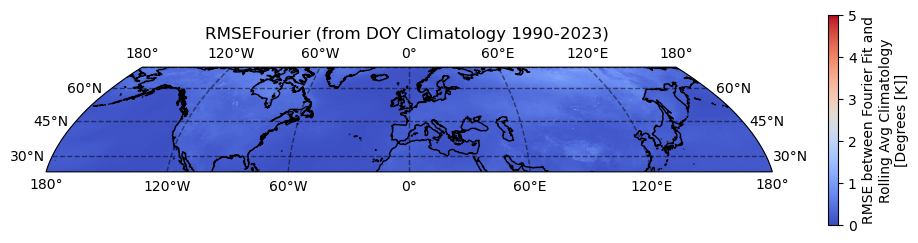

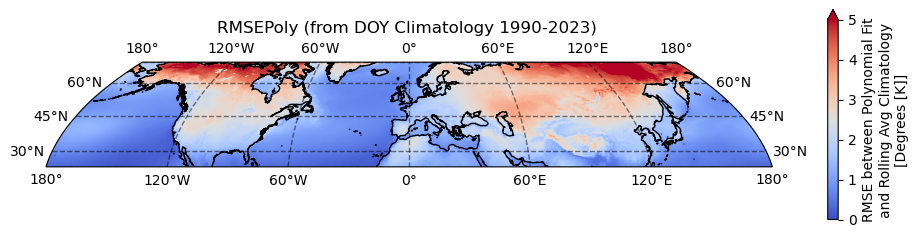

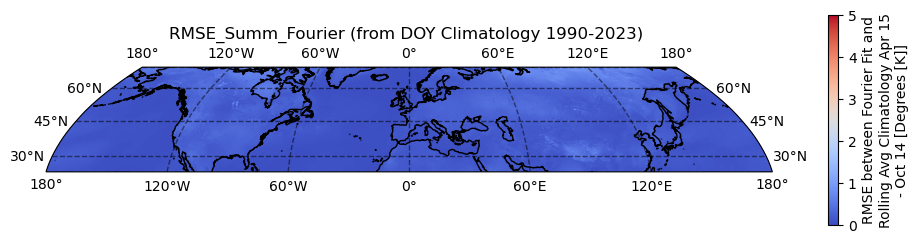

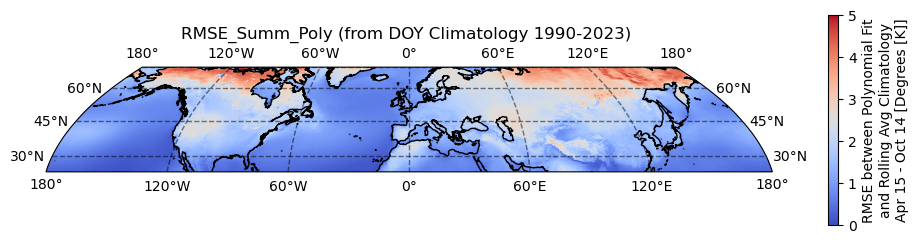

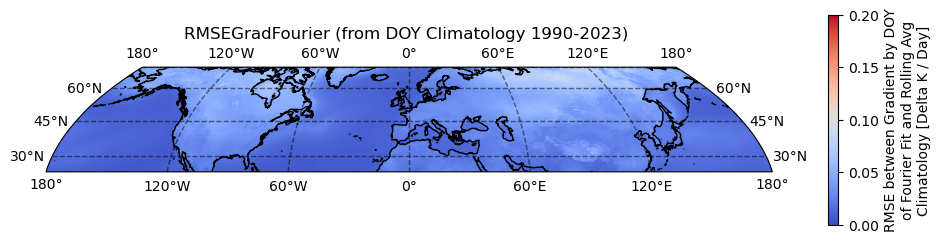

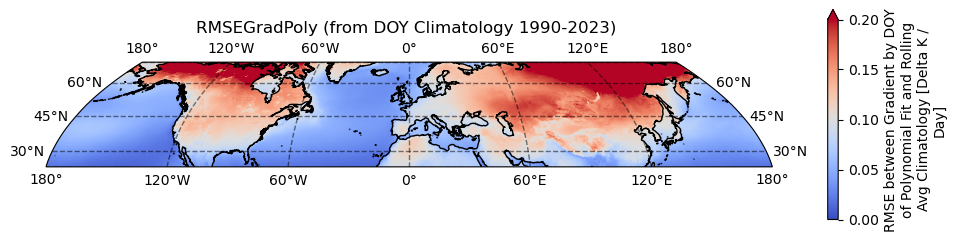

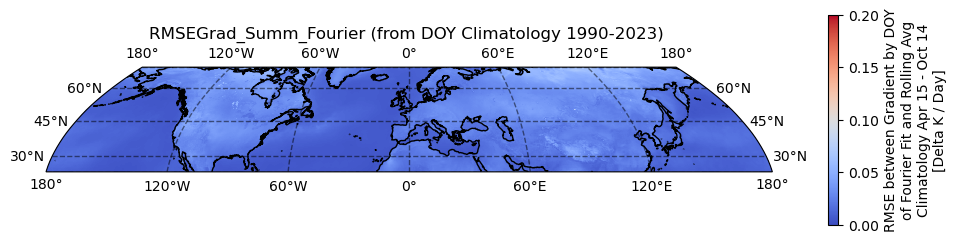

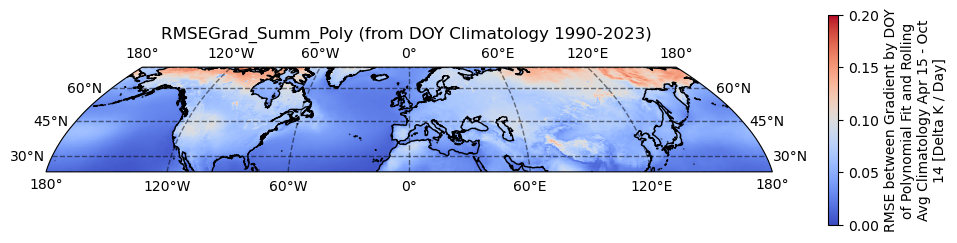

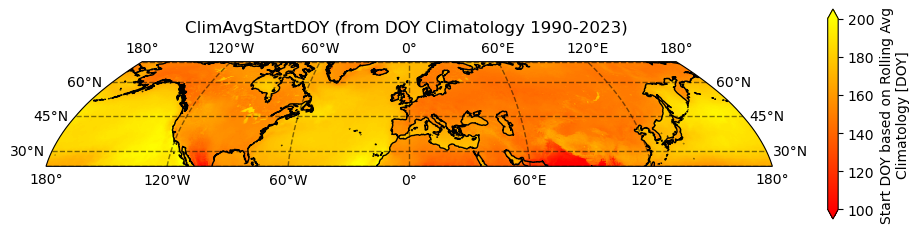

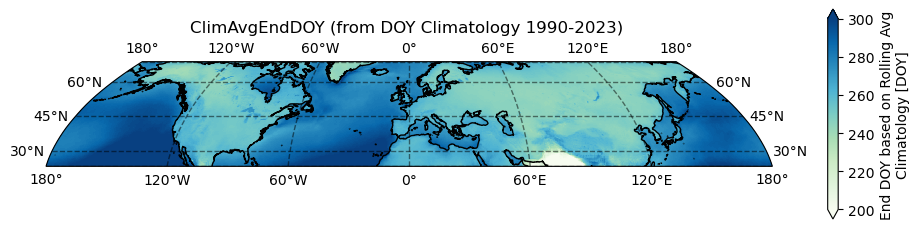

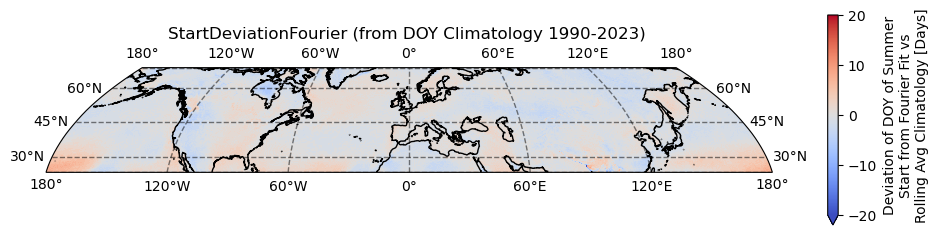

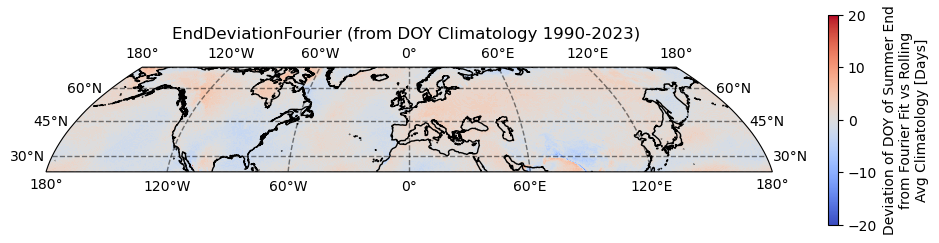

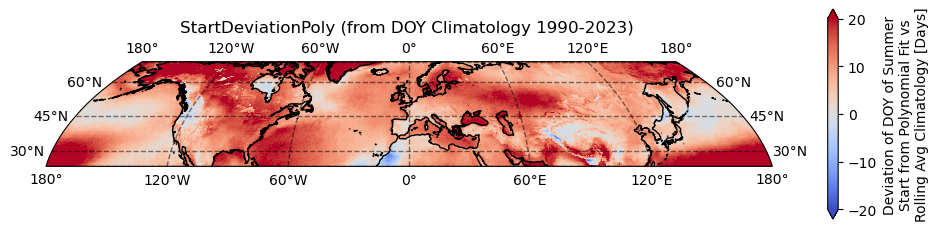

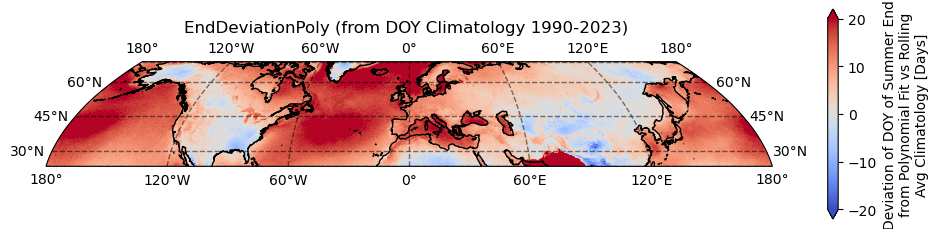

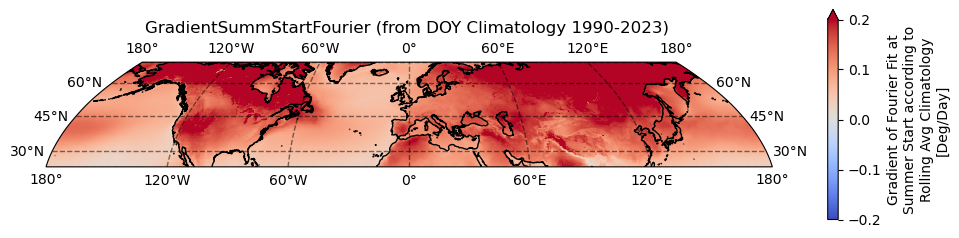

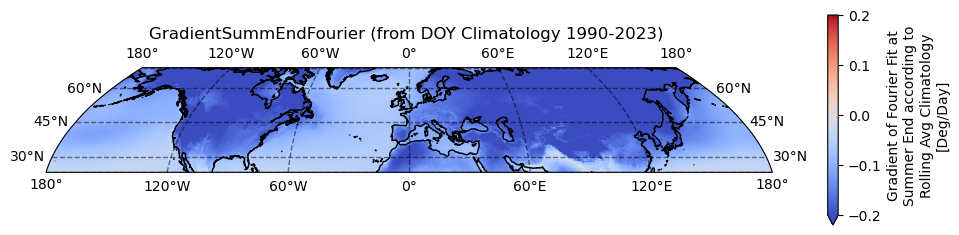

CPU times: user 40.9 s, sys: 985 ms, total: 41.9 s
Wall time: 42.1 s


<Figure size 640x480 with 0 Axes>

In [33]:
%%time

# takes 3.5 min

# limits for ranges on plots
lims = [[0,5], #RMSEFourier
        [0,5], #RMSEPoly
        [0,5], #RMSE_Summ_Fourier
        [0,5], #RMSE_Summ_Poly
        [0,0.2], #RMSEGradFourier
        [0,0.2], # RMSEGradPoly
        [0,0.2], #RMSEGrad_Summ_Fourier
        [0,0.2], # RMSEGrad_Summ_Poly
        [100,200], # ClimAvgStartDOY
        [200,300], # ClimAvgEndDOY
        [-20,20], #StartDeviationFourier
        [-20,20], # EndDeviationFourier
        [-20,20], #StartDeviationPoly
        [-20,20], # EndDeviationPoly
        [-0.2,0.2], #GradientSummStartFourier
        [-0.2,0.2] #GradientSummEndFourier
       ]

colors = ['coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'autumn',
          'GnBu',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm'
         ]

# loop through all plot variables
for i,v in enumerate(plot_vars):


    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(2,1,1,projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax1.coastlines()
    ax1.gridlines(draw_labels=True,linewidth=1, color='black', alpha=0.5,  ylocs=mticker.FixedLocator([ 23.5,30,45,60, 70]), linestyle='--')
    # assign axis and def projection to use
    #ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    # ax.coastlines()
    # ax.gridlines()
    
    grad_ds_temp[v].plot(
        ax=ax1,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=lims[i][0],
        vmax=lims[i][1], # define range to include an entire year
        cmap=colors[i]#"YlOrRd"#cmap="coolwarm"
    )
    
    ax1.set_title(v + " (from DOY Climatology 1990-2023) ")
    plt.savefig("./Plots/1990-2023_DOYClim_"+v+"_NH.png")

    # ax2 = fig.add_subplot(2,1,2,projection=ccrs.Robinson(central_longitude=0))
    
    
    # # add coastlines and grid
    # ax2.coastlines()
    # ax2.gridlines()
    
    # grad_ds_temp[v].plot(
    #     ax=ax2,
    #     transform=ccrs.PlateCarree(), # assign map projection
    #     vmin=0,
    #     vmax=0.2, # define range to include an entire year
    #     cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    # )
    
    # ax2.set_title("RMSE Polynomial Gradient (from DOY Climatology 1990-2023) ")

plt.show()
plt.tight_layout()



### Just the RMSE plots for latitude dependence

#### version for paper - saving as PDF, EPS, and SVG to hopefully get good color transfer to PPT

In [34]:
plot_vars = ['RMSEFourier','RMSEPoly','RMSE_Summ_Fourier','RMSE_Summ_Poly' ]

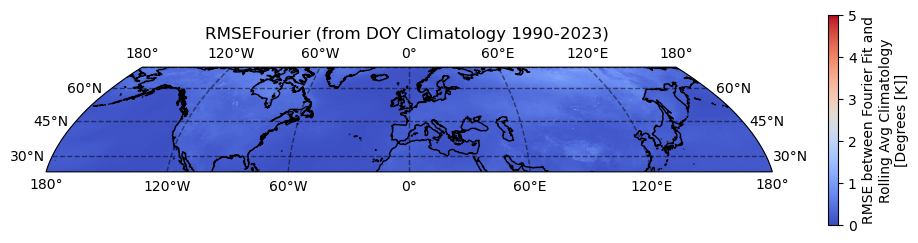

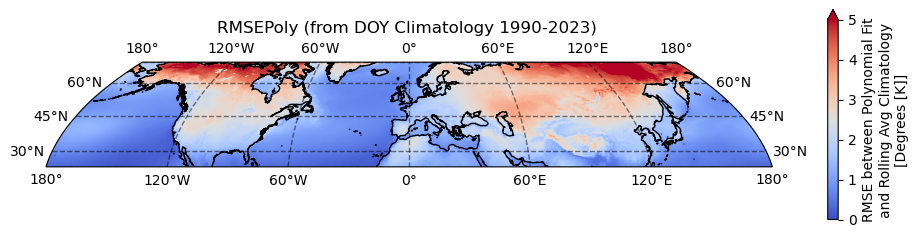

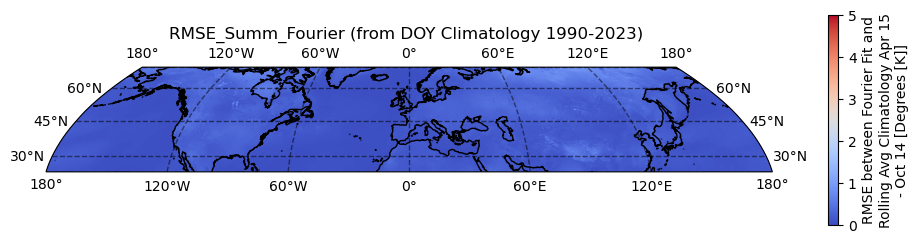

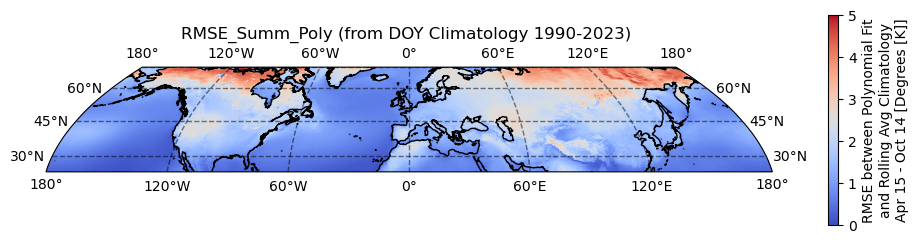

CPU times: user 35.2 s, sys: 669 ms, total: 35.9 s
Wall time: 36 s


<Figure size 640x480 with 0 Axes>

In [35]:
%%time

# takes 3.5 min

# limits for ranges on plots
lims = [[0,5], #RMSEFourier
        [0,5], #RMSEPoly
        [0,5], #RMSE_Summ_Fourier
        [0,5], #RMSE_Summ_Poly
       ]

colors = ['coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
         ]

# loop through all plot variables
for i,v in enumerate(plot_vars):


    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(2,1,1,projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax1.coastlines()
    ax1.gridlines(draw_labels=True,linewidth=1, color='black', alpha=0.5,  ylocs=mticker.FixedLocator([ 23.5,30,45,60, 70]), linestyle='--')
    
    grad_ds_temp[v].plot(
        ax=ax1,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=lims[i][0],
        vmax=lims[i][1], # define range to include an entire year
        cmap=colors[i]#"YlOrRd"#cmap="coolwarm"
    )
    
    ax1.set_title(v + " (from DOY Climatology 1990-2023) ")
    plt.savefig("./Plots/1990-2023_DOYClim_"+v+"_NH.pdf")


plt.show()
plt.tight_layout()



In [36]:
plot_vars

['RMSEFourier', 'RMSEPoly', 'RMSE_Summ_Fourier', 'RMSE_Summ_Poly']

#### relabel, adjust units, and make better plot for publication?

In [37]:
# make a copy to keep original intact
res_plot = grad_ds_temp[plot_vars].copy(deep=True)

# update attributes
res_plot['RMSEFourier'].attrs["long_name"] = "RMSE"
res_plot['RMSEFourier'].attrs["units"] = "$^{\circ}$C"
res_plot['RMSEPoly'].attrs["long_name"] = "RMSE"
res_plot['RMSEPoly'].attrs["units"] = "$^{\circ}$C"
res_plot['RMSE_Summ_Fourier'].attrs["long_name"] = "RMSE Apr 15 - Oct 14"
res_plot['RMSE_Summ_Fourier'].attrs["units"] = "$^{\circ}$C"
res_plot['RMSE_Summ_Poly'].attrs["long_name"] = "RMSE Apr 15 - Oct 14"
res_plot['RMSE_Summ_Poly'].attrs["units"] = "$^{\circ}$C"

res_plot

<xarray.Dataset> Size: 9MB
Dimensions:            (lat: 187, lon: 1440)
Coordinates:
  * lat                (lat) float64 1kB 23.5 23.75 24.0 ... 69.5 69.75 70.0
  * lon                (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    RMSEFourier        (lat, lon) float64 2MB ...
    RMSEPoly           (lat, lon) float64 2MB ...
    RMSE_Summ_Fourier  (lat, lon) float64 2MB ...
    RMSE_Summ_Poly     (lat, lon) float64 2MB ...

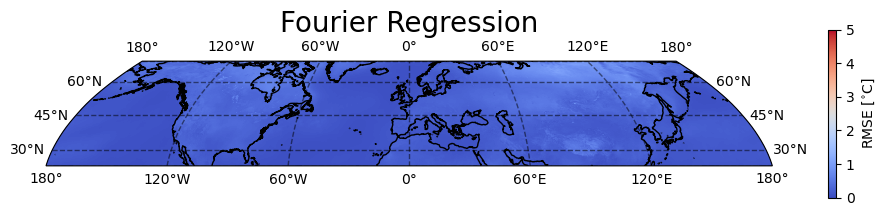

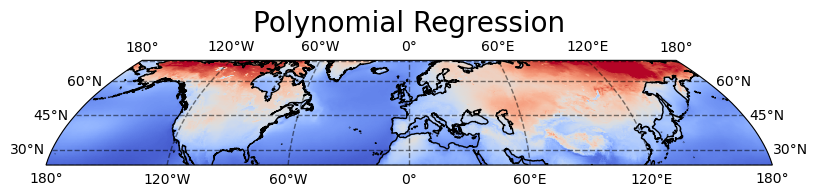

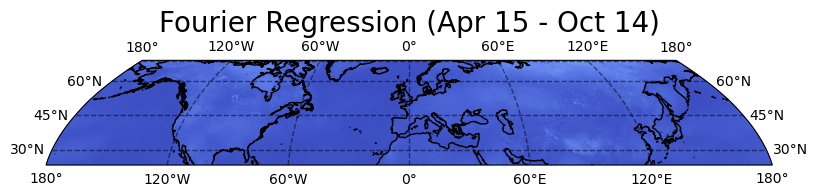

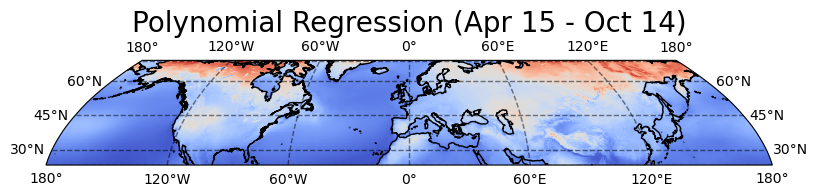

CPU times: user 38.6 s, sys: 721 ms, total: 39.4 s
Wall time: 39.4 s


<Figure size 640x480 with 0 Axes>

In [39]:
%%time

# takes 3.5 min

# limits for ranges on plots
lims = [[0,5], #RMSEFourier
        [0,5], #RMSEPoly
        [0,5], #RMSE_Summ_Fourier
        [0,5], #RMSE_Summ_Poly
       ]

colors = ['coolwarm',
          'coolwarm',
          'coolwarm',
          'coolwarm',
         ]

titles = ['Fourier Regression','Polynomial Regression', 'Fourier Regression (Apr 15 - Oct 14)','Polynomial Regression (Apr 15 - Oct 14)']


# loop through all plot variables
for i,v in enumerate(plot_vars):


    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(2,1,1,projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax1.coastlines()
    ax1.gridlines(draw_labels=True,linewidth=1, color='black', alpha=0.5,  
                  ylocs=mticker.FixedLocator([ 23.5,30,45,60, 70]), linestyle='--')#,xlabels_top=False)
    
    res_plot[v].plot(
        ax=ax1,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=lims[i][0],
        vmax=lims[i][1], # define range to include an entire year
        cmap=colors[i],
        cbar_kwargs={'shrink':0.8}
        
    )
    if i>=1:
        fig.axes[-1].remove()
    
    ax1.set_title(titles[i], fontsize=20)
    plt.savefig("./Plots/1990-2023_DOYClim_"+v+"_NH.pdf",bbox_inches='tight')
    plt.savefig("./Plots/1990-2023_DOYClim_"+v+"_NH.png",bbox_inches='tight')

plt.show()
plt.tight_layout()




# * BELOW NOT UPDATED

In [28]:
plot_vars_rmse = list(grad_ds_temp.data_vars)
remove_me_rmse = {'lsm','Coastal','ClimAvgStartDOY',
 'ClimAvgEndDOY',
 'StartDeviationFourier',
 'EndDeviationFourier',
 'StartDeviationPoly',
 'EndDeviationPoly',
 'GradientSummStartFourier',
 'GradientSummEndFourier'}
plot_vars_rmse = [item for item in plot_vars_rmse if item not in remove_me_rmse]
plot_vars_rmse

['RMSEFourier', 'RMSEPoly', 'RMSEGradFourier', 'RMSEGradPoly']

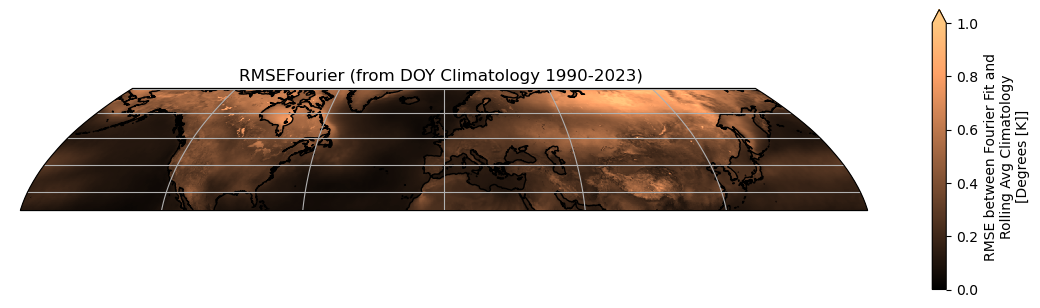

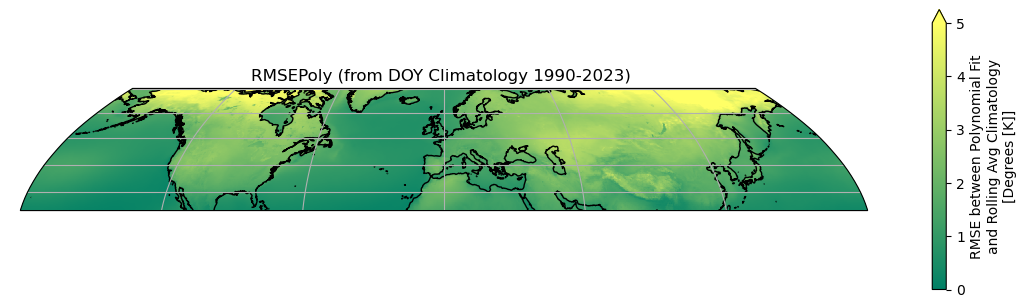

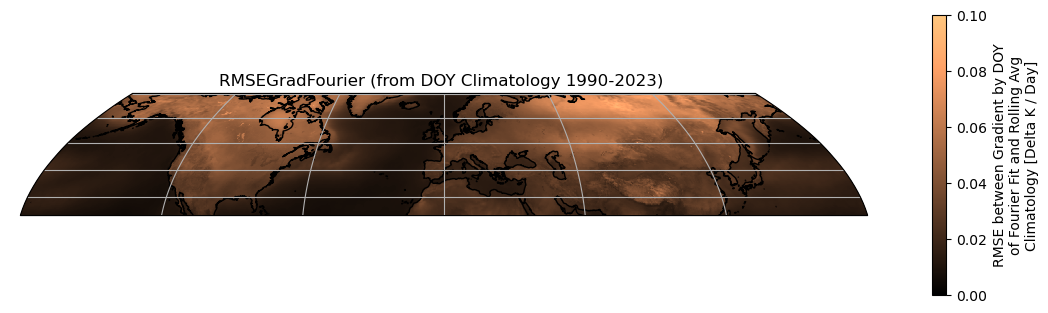

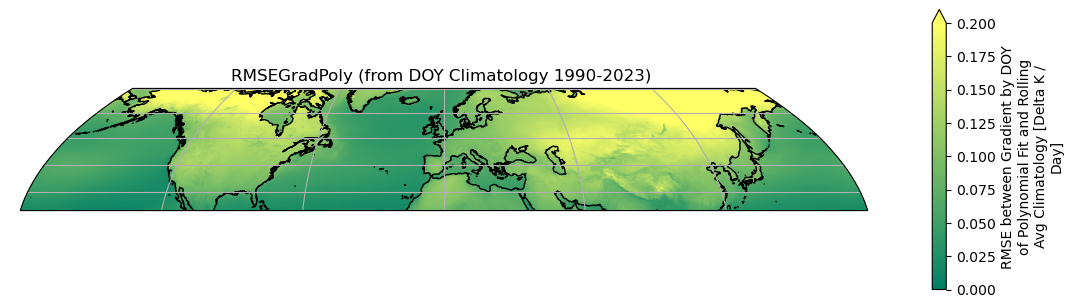

CPU times: user 3.88 s, sys: 119 ms, total: 4 s
Wall time: 3.99 s


<Figure size 640x480 with 0 Axes>

In [29]:
%%time

# takes XX min

# limits for ranges on plots
lims = [[0,1], #RMSEFourier
        [0,5], #RMSEPoly
        [0,0.1], #RMSEGradFourier
        [0,0.2], # RMSEGradPoly
       ]

colors = ['copper',
          'summer',
          'copper',
          'summer',
         ]

# loop through all plot variables
for i,v in enumerate(plot_vars_rmse):


    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(14,8))
    ax1 = fig.add_subplot(2,1,1,projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax1.coastlines()
    ax1.gridlines()
    
    grad_ds_temp[v].plot(
        ax=ax1,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=lims[i][0],
        vmax=lims[i][1], # define range to include an entire year
        cmap=colors[i]#"YlOrRd"#cmap="coolwarm"
    )
    
    ax1.set_title(v + " (from DOY Climatology 1990-2023) ")



plt.show()
plt.tight_layout()



In [25]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(grad_ds_temp.lat))
weights.name = "weights"

### Zonal Means of the RMSEs

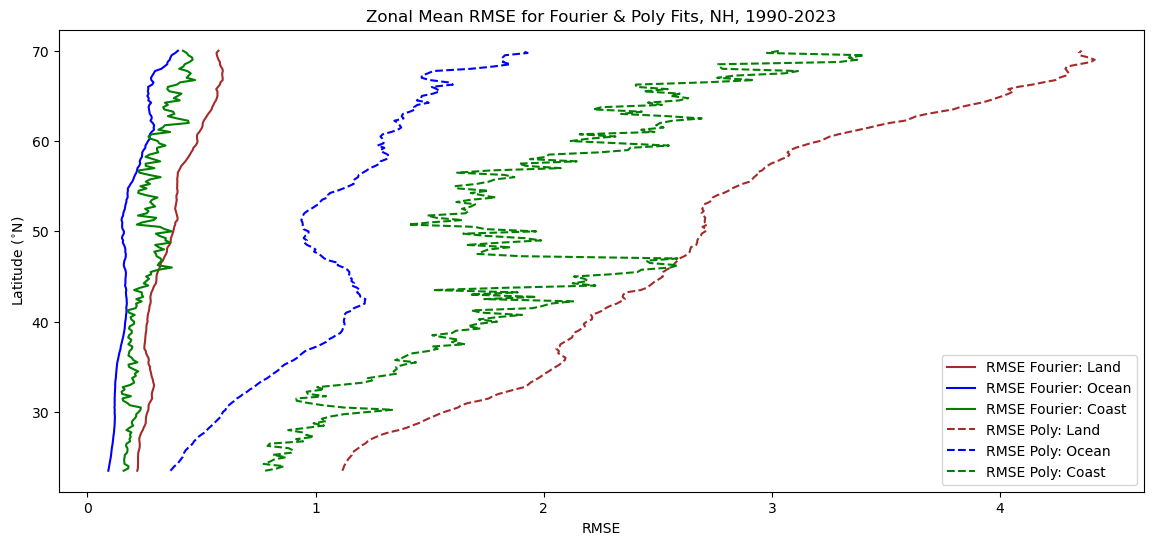

In [36]:
plt.figure(figsize=(14,6))
zonal_mean_land_f = grad_ds_temp.RMSEFourier.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_f = grad_ds_temp.RMSEFourier.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_f = grad_ds_temp.RMSEFourier.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
zonal_mean_land_p = grad_ds_temp.RMSEPoly.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_p = grad_ds_temp.RMSEPoly.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_p = grad_ds_temp.RMSEPoly.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
latitude = grad_ds_temp.lat
plt.plot(zonal_mean_land_f, latitude, c='brown', label='RMSE Fourier: Land')
plt.plot(zonal_mean_ocean_f, latitude, c='blue', label='RMSE Fourier: Ocean')
plt.plot(zonal_mean_coast_f, latitude, c='green', label='RMSE Fourier: Coast')
plt.plot(zonal_mean_land_p, latitude, c='brown', linestyle='dashed', label='RMSE Poly: Land')
plt.plot(zonal_mean_ocean_p, latitude, c='blue', linestyle='dashed', label='RMSE Poly: Ocean')
plt.plot(zonal_mean_coast_p, latitude, c='green', linestyle='dashed', label='RMSE Poly: Coast')
plt.legend()
plt.xlabel("RMSE")
plt.ylabel("Latitude ($^{\circ}$N)")
plt.title('Zonal Mean RMSE for Fourier & Poly Fits, NH, 1990-2023')
plt.show()

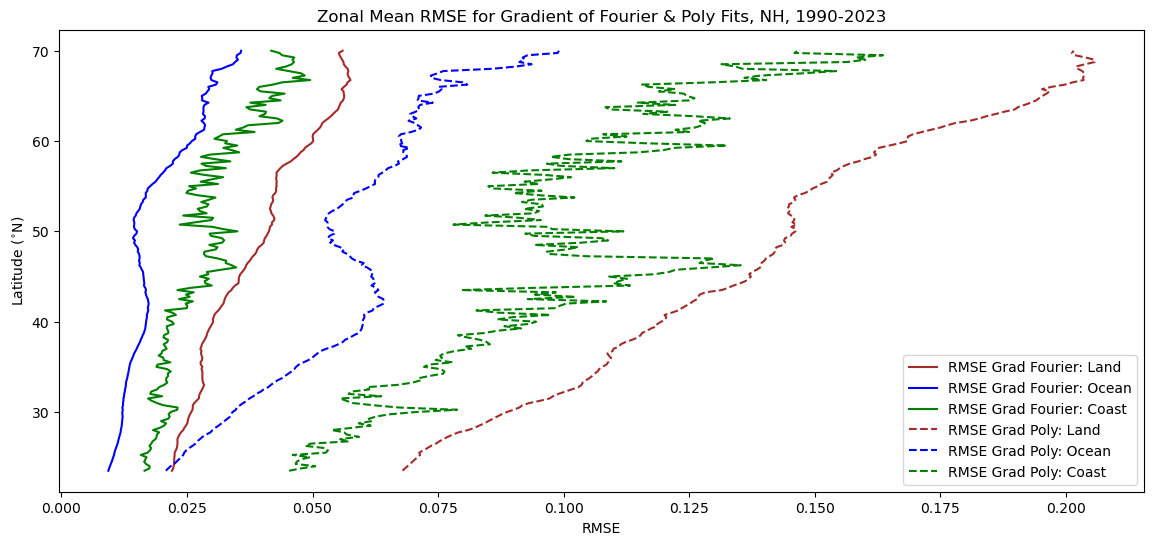

In [37]:
# RMSE of Gradient of Fit
plt.figure(figsize=(14,6))
zonal_mean_land_f = grad_ds_temp.RMSEGradFourier.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_f = grad_ds_temp.RMSEGradFourier.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_f = grad_ds_temp.RMSEGradFourier.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
zonal_mean_land_p = grad_ds_temp.RMSEGradPoly.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_p = grad_ds_temp.RMSEGradPoly.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_p = grad_ds_temp.RMSEGradPoly.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
latitude = grad_ds_temp.lat
plt.plot(zonal_mean_land_f, latitude, c='brown', label='RMSE Grad Fourier: Land')
plt.plot(zonal_mean_ocean_f, latitude, c='blue', label='RMSE Grad Fourier: Ocean')
plt.plot(zonal_mean_coast_f, latitude, c='green', label='RMSE Grad Fourier: Coast')
plt.plot(zonal_mean_land_p, latitude, c='brown', linestyle='dashed', label='RMSE Grad Poly: Land')
plt.plot(zonal_mean_ocean_p, latitude, c='blue', linestyle='dashed', label='RMSE Grad Poly: Ocean')
plt.plot(zonal_mean_coast_p, latitude, c='green', linestyle='dashed', label='RMSE Grad Poly: Coast')
plt.legend()
plt.xlabel("RMSE")
plt.ylabel("Latitude ($^{\circ}$N)")
plt.title('Zonal Mean RMSE for Gradient of Fourier & Poly Fits, NH, 1990-2023')
plt.show()

### Zonal Means of the Gradients at start and end

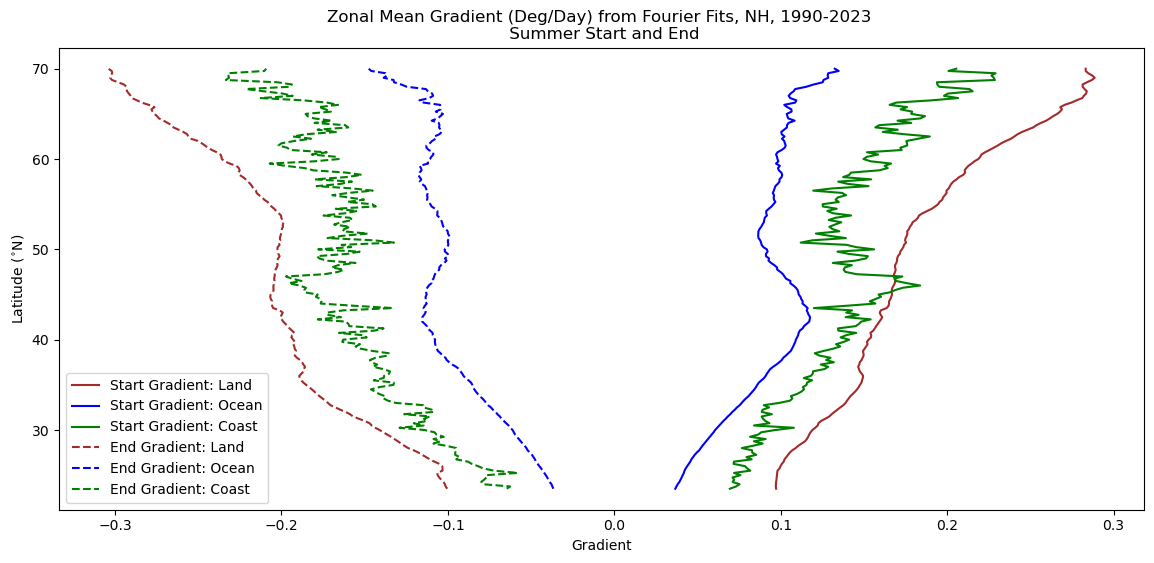

In [30]:
plt.figure(figsize=(14,6))
zonal_mean_land_start = grad_ds_temp.GradientSummStartFourier.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_start = grad_ds_temp.GradientSummStartFourier.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_start = grad_ds_temp.GradientSummStartFourier.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
zonal_mean_land_end = grad_ds_temp.GradientSummEndFourier.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_ocean_end = grad_ds_temp.GradientSummEndFourier.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).mean(dim=['lon'])
zonal_mean_coast_end = grad_ds_temp.GradientSummEndFourier.where((grad_ds_temp.Coastal == True)).mean(dim=['lon'])
latitude = grad_ds_temp.lat
plt.plot(zonal_mean_land_start, latitude, c='brown', label='Start Gradient: Land')
plt.plot(zonal_mean_ocean_start, latitude, c='blue', label='Start Gradient: Ocean')
plt.plot(zonal_mean_coast_start, latitude, c='green', label='Start Gradient: Coast')
plt.plot(zonal_mean_land_end, latitude, c='brown', linestyle='dashed', label='End Gradient: Land')
plt.plot(zonal_mean_ocean_end, latitude, c='blue', linestyle='dashed', label='End Gradient: Ocean')
plt.plot(zonal_mean_coast_end, latitude, c='green', linestyle='dashed', label='End Gradient: Coast')
plt.legend()
plt.xlabel("Gradient")
plt.ylabel("Latitude ($^{\circ}$N)")
plt.title('Zonal Mean Gradient (Deg/Day) from Fourier Fits, NH, 1990-2023 \n Summer Start and End')
plt.show()

## NOT GOING TO DOBar plots for means by land/coast/ocean

In [24]:
# build nh_land_full etc for poly fits


nh_land = grad_ds_temp.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).weighted(weights).mean(dim=['lat','lon'])
nh_land_std = grad_ds_temp.where((grad_ds_temp.lsm > 0.5) & (grad_ds_temp.Coastal == False)).weighted(weights).std(dim=['lat','lon'])

nh_coast = grad_ds_temp.where((grad_ds_temp.Coastal)).weighted(weights).mean(dim=['lat','lon'])
nh_coast_std = grad_ds_temp.where((grad_ds_temp.Coastal)).weighted(weights).std(dim=['lat','lon'])

nh_ocean = grad_ds_temp.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).weighted(weights).mean(dim=['lat','lon'])
nh_ocean_std = grad_ds_temp.where((grad_ds_temp.lsm <= 0.5) & (grad_ds_temp.Coastal == False)).weighted(weights).std(dim=['lat','lon'])

In [145]:
nh_land, nh_coast, nh_ocean

(<xarray.Dataset> Size: 96B
 Dimensions:                ()
 Data variables:
     RMSEFourier            float64 8B 0.356
     RMSEPoly               float64 8B 2.539
     RMSEGradFourier        float64 8B 0.03744
     RMSEGradPoly           float64 8B 0.1339
     ClimAvgStartDOY        float64 8B 149.2
     ClimAvgEndDOY          float64 8B 252.9
     StartDeviationFourier  float64 8B -0.8883
     EndDeviationFourier    float64 8B 0.7354
     StartDeviationPoly     float64 8B 10.98
     EndDeviationPoly       float64 8B 4.18
     lsm                    float64 8B 0.9749
     Coastal                float64 8B 0.0,
 <xarray.Dataset> Size: 96B
 Dimensions:                ()
 Data variables:
     RMSEFourier            float64 8B 0.268
     RMSEPoly               float64 8B 1.868
     RMSEGradFourier        float64 8B 0.02837
     RMSEGradPoly           float64 8B 0.09721
     ClimAvgStartDOY        float64 8B 160.7
     ClimAvgEndDOY          float64 8B 266.0
     StartDeviationFourier  f

### Need to build a dataframe form the data to make the barplots

In [ ]:
# %%time

# # takes 30 sec



# # loop through all plot variables
# for i,v in enumerate(plot_vars):

#     # create blank fig
#     fig = plt.figure(figsize = (16,8))
    
#     # Full Time Period NH
#     ax1 = fig.add_subplot(1,1,1)
#     #ax1 = fig.add_subplot(1,3,1)

#     # linear fits for slope - land
#     x_land = nh_land.time.dt.year.values
#     y_land = nh_land[v].values
#     coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
#     poly_land = np.poly1d(coefs_land)
#     slope_land = np.round(coefs_land[0],3)
#     slope_land_sd = np.round(np.sqrt(V[0][0]),3)  
#     # add in R^2 and RMSE
#     ymean = np.mean(y_land)
#     ss_total = np.sum((y_land - ymean)**2)
#     ss_res = np.sum((y_land - poly_land(x_land))**2)
#     #rmse = np.sqrt(ss_res/365.0)
#     r_squared_land = np.round(1 - (ss_res / ss_total),2)
    

#     # linear fits for slope - coasts
#     x_coast = nh_coast_full.time.dt.year.values
#     y_coast = nh_coast_full[v].values
#     coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
#     poly_coast = np.poly1d(coefs_coast)
#     slope_coast = np.round(coefs_coast[0],3)
#     slope_coast_sd = np.round(np.sqrt(V[0][0]),3)  
#     # add in R^2 and RMSE
#     ymean = np.mean(y_coast)
#     ss_total = np.sum((y_coast - ymean)**2)
#     ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#     #rmse = np.sqrt(ss_res/365.0)
#     r_squared_coast = np.round(1 - (ss_res / ss_total),2)
    

#     # linear fits for slope - ocean
#     x_ocean = nh_ocean_full.time.dt.year.values
#     y_ocean = nh_ocean_full[v].values
#     coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
#     poly_ocean = np.poly1d(coefs_ocean)
#     slope_ocean = np.round(coefs_ocean[0],3)
#     slope_ocean_sd = np.round(np.sqrt(V[0][0]),3)  
#     # add in R^2 and RMSE
#     ymean = np.mean(y_ocean)
#     ss_total = np.sum((y_ocean - ymean)**2)
#     ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#     #rmse = np.sqrt(ss_res/365.0)
#     r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

    
#     # plot data
#     ax1.scatter(x_ocean, y_ocean, label="NH Ocean F", c="blue", alpha=0.2)
    
#     ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', linewidth=lw,
#          label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

#     ax1.scatter(x_coast, y_coast, label="NH Coast F", c="darkgreen", alpha=0.2)
    
#     ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', linewidth=lw,
#              label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    
#     ax1.scatter(x_land, y_land, label="NH Inland F", c="brown", alpha=0.2)
    
#     ax1.plot(x_land, poly_land(x_land), linestyle="dashed", color='brown',linewidth=lw,
#          label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    
#     ax1.set_title("NH [23.5, 70 N] " + v + " (1990-2023)", fontsize = 10)
#     ax1.legend(loc='best')
